# 10 · Gradient Boosting Ailesi (AdaBoost, Gradient Boosting Machines, XGBoost, LightGBM, CatBoost)
**Classical ML Lab** · Sıralı/Düzeltici Ensemble, Zayıf Öğreniciler, Gradyan İnişi Fonksiyon Uzayında

---
> **Bu notebook'ta ne öğreneceğiz?**
> `09_bagging_random_forest`'te ensemble öğrenmenin **paralel/bağımsız** koluna baktık: Bagging, Random Forest ve Extra Trees, birbirinden bağımsız yüksek-varyanslı ağaçları ortalayarak **varyansı** azaltıyordu. Bu notebook, ensemble ailesinin ikinci büyük koluna odaklanıyor: **Boosting** — modelleri paralel değil **sıralı** eğiten, her yeni modelin bir öncekinin hatalarını düzeltmeye odaklandığı, düşük-varyanslı ama yüksek-yanlılıklı (high-bias) zayıf öğrenicileri birleştirerek **yanlılığı (bias)** azaltan bir yaklaşım. Bu notebook'ta: (1) **AdaBoost**'u (Adaptive Boosting) sıfırdan implemente edip örnek ağırlıklarının nasıl evrildiğini göreceğiz, (2) **Gradient Boosting Machines (GBM)**'i fonksiyon uzayında gradyan inişi olarak sıfırdan kuracağız (pseudo-residual fitting), (3) modern, üretim-kalitesinde üç kütüphaneyi — **XGBoost**, **LightGBM**, **CatBoost** — hem teorik farklarıyla (regularizasyon, histogram tabanlı bölünme, sıralı boosting, kategorik değişken desteği) hem de gerçek veride hız/performans karşılaştırmalarıyla inceleyeceğiz, (4) dengesiz sınıf (imbalanced class), erken durdurma (early stopping) ve kategorik değişkenlerin native desteği gibi pratik/üretim konularını ele alacağız, ve (5) beş algoritmayı aynı veri setinde uçtan uca karşılaştıracağız. Bu notebook `03_tree_based_models` klasöründeki ağaç-tabanlı yöntemler kategorisinin son notebook'u — bir sonraki kategori (`04_model_evaluation_improvement`) model değerlendirme ve iyileştirme tekniklerine geçecek.
>
> **Önkoşul:** `08_decision_trees` (CART, Gini/Entropi — her boosting algoritmasının zayıf öğrenicisi de bir karar ağacı), `09_bagging_random_forest` (ensemble kavramı, bias-varyans ayrışımı, OOB, MDI/permütasyon önemi — bu notebook'un doğrudan karşılaştırma noktası).
> **Veri:** UCI/Kaggle Estimation of Obesity Levels (Palechor & de la Hoz Manotas 2019 — beslenme/yaşam tarzı alışkanlıklarından obezite seviyesi tahmini, 7 sınıflı çok-sınıflı sınıflandırma, 2.111 örnek), UCI Bank Marketing (Moro, Cortez & Rita 2014 — Portekiz bankasının telefon pazarlama kampanyasında vadeli mevduat aboneliği tahmini, ikili sınıflandırma, doğal olarak dengesiz [%11.7 pozitif], 45.211 örnek, 9 kategorik + 7 sayısal özellik), UCI Student Performance (Cortez & Silva 2008 — Portekiz'de lise matematik dersi final notu tahmini, regresyon, 395 örnek, 17 kategorik + 15 sayısal özellik, CatBoost'un native kategorik desteğini göstermek için ideal).
> **Araçlar:** Python (`scikit-learn` — `AdaBoostClassifier/Regressor`, `GradientBoostingClassifier/Regressor`; `xgboost`; `lightgbm`; `catboost`), R (`adabag`, `gbm`, `xgboost`, `lightgbm` paketleri — CatBoost'un R paketi CRAN'da olmadığından [GitHub release'den kurulması gerekiyor] bu notebook'ta R koduna dahil edilmedi, bkz. Kaynaklar), SQL (DuckDB — AdaBoost'un ağırlıklı oy toplamının ve GBM'in ardışık ağaç toplamının SQL'de yeniden üretimi).

---
## 1 · Boosting'e Giriş: Sıralı Ensemble ve Zayıf Öğreniciler

**Bagging'den (09) farkı.** Bagging ailesi, birbirinden **bağımsız** (paralel eğitilen) yüksek-varyanslı modelleri ortalayarak varyansı azaltıyordu — her ağaç kendi bootstrap örneklemine bakıyor, diğerlerinden habersiz. **Boosting** tam tersi bir felsefeyle çalışır: modeller **sıralı (sequential)** eğitilir ve her yeni model, kendinden önceki modellerin **hatalarına** odaklanır. Bagging varyansı azaltırken, boosting öncelikle **yanlılığı (bias)** azaltır — çünkü tek başına zayıf (yüksek yanlılıklı) modelleri, hataları telafi edecek şekilde birleştirir.

**Zayıf Öğrenici (Weak Learner) Kavramı.** Boosting'in orijinal motivasyonu (Kearns & Valiant 1988'in "Zayıf Öğrenilebilirlik" problemi) şu soruyla başladı: rastgele tahminden *biraz* daha iyi olan (örneğin ikili sınıflandırmada hata oranı $< 0.5$) birçok "zayıf" sınıflandırıcıyı birleştirip *keyfi derecede güçlü* bir sınıflandırıcı elde edebilir miyiz? Schapire (1990) ve ardından Freund & Schapire (1997) bu sorunun cevabının **evet** olduğunu, AdaBoost algoritmasıyla kanıtladı. Pratikte zayıf öğrenici neredeyse her zaman **sığ bir karar ağacı**dır — genellikle bir **karar güdüğü (decision stump, derinlik=1)** ya da derinliği 3-8 arası sığ bir ağaç.

**Genel Boosting Şeması.** Tüm boosting algoritmaları şu iskeleti paylaşır:
1. Basit bir başlangıç modeliyle başla ($F_0(x)$ — örn. sabit bir tahmin).
2. $m = 1, \dots, M$ için: mevcut modelin ($F_{m-1}$) **hatalarına odaklanan** yeni bir zayıf öğrenici $h_m$ eğit.
3. $h_m$'i mevcut modele bir ağırlıkla ekle: $F_m(x) = F_{m-1}(x) + \nu \cdot \alpha_m h_m(x)$ ($\nu$: öğrenme oranı/shrinkage).
4. $M$ tur sonunda nihai tahmin $F_M(x)$'tir.

Farklı boosting algoritmaları, bu şemanın **"hataya odaklanma" adımını nasıl tanımladıkları** ile ayrışır: AdaBoost yanlış sınıflandırılan örneklerin **ağırlığını** artırır (sonraki zayıf öğrenici bu ağırlıklı veriye odaklanır); GBM ve türevleri (XGBoost/LightGBM/CatBoost) ise doğrudan kayıp fonksiyonunun **gradyanına** (pseudo-residual) uyum sağlar — bu yüzden "Gradient Boosting" adını alırlar. AdaBoost, gradient boosting'in üstel kayıp (exponential loss) ile özel bir durumu olarak da görülebilir (Friedman, Hastie & Tibshirani 2000, "Additive Logistic Regression: A Statistical View of Boosting").

**Bias-Varyans Perspektifinden Boosting'in Riski.** Bagging'in aksine boosting, çok fazla tur (yüksek $M$) çalıştırıldığında **aşırı öğrenmeye (overfitting)** boosting-özel bir yolla eğilimlidir: model eğitim verisindeki gürültülü/aykırı noktalara giderek daha fazla ağırlık vererek onlara da uymaya çalışabilir. Bu yüzden boosting ailesinde `n_estimators`, `learning_rate` ve **erken durdurma (early stopping)** birbirine sıkı sıkıya bağlı, dikkatle ayarlanması gereken hiperparametrelerdir — bu notebook'un son teorik bölümünde ve Python uygulamasında bu üçlüyü ayrıntılı işleyeceğiz.

**Endüstride nerede kullanılır?** Boosting ailesi — özellikle modern gradient boosting kütüphaneleri — tablosal (tabular) verilerde derin öğrenmeyi bile geride bırakan, endüstride en yaygın kullanılan denetimli öğrenme yöntemleri arasındadır: kredi skorlama ve dolandırıcılık tespiti (finans), tıklama oranı (CTR) tahmini ve reklam sıralaması (ad-tech, arama motorları), talep/satış tahmini (perakende), ve neredeyse tüm Kaggle yarışmalarının kazanan çözümlerinde (bkz. XGBoost makalesinin kendi istatistiği: 2015'te Kaggle'da düzenlenen 29 yarışmanın 17'sinin kazanan çözümü XGBoost kullanmıştı).

---
## 2 · AdaBoost (Adaptive Boosting)

**Algoritma (ikili sınıflandırma, $y \in \{-1, +1\}$).** $n$ eğitim örneği için başlangıçta tüm örnekler eşit ağırlıklıdır: $w_i^{(1)} = 1/n$. Her tur $m = 1, \dots, M$ için:

1. Ağırlıklı veriyle bir zayıf öğrenici eğit: $h_m = \arg\min_h \sum_i w_i^{(m)} \cdot \mathbb{1}[y_i \neq h(x_i)]$.
2. Ağırlıklı hata oranını hesapla: $\varepsilon_m = \dfrac{\sum_i w_i^{(m)} \cdot \mathbb{1}[y_i \neq h_m(x_i)]}{\sum_i w_i^{(m)}}$.
3. Zayıf öğrenicinin ağırlığını (güven skoru) hesapla: $\alpha_m = \dfrac{1}{2} \ln\left(\dfrac{1-\varepsilon_m}{\varepsilon_m}\right)$.
4. Örnek ağırlıklarını güncelle (yanlış sınıflandırılanların ağırlığı artar, doğru sınıflandırılanlarınki azalır): $w_i^{(m+1)} = w_i^{(m)} \cdot \exp(-\alpha_m y_i h_m(x_i))$, sonra normalize et ($\sum_i w_i^{(m+1)} = 1$).

Nihai tahmin, her zayıf öğrenicinin **güven-ağırlıklı oyu**dur: $H(x) = \text{sign}\left(\sum_{m=1}^{M} \alpha_m h_m(x)\right)$.

**$\alpha_m$'in sezgisi.** $\varepsilon_m < 0.5$ (zayıf öğrenici rastgele tahminden iyi) olduğu sürece $\alpha_m > 0$'dır — hata oranı düştükçe $\alpha_m$ hızla büyür (çok iyi bir zayıf öğrenici oya daha çok ağırlık kazanır). $\varepsilon_m = 0.5$'te $\alpha_m = 0$ (rastgele tahmin eden bir öğrenici hiç oy hakkı almaz). $w_i$ güncellemesindeki $\exp(-\alpha_m y_i h_m(x_i))$ terimi, doğru sınıflandırılan noktalarda ($y_i h_m(x_i) = 1$) ağırlığı $e^{-\alpha_m}$ ile çarparak **azaltır**, yanlış sınıflandırılanlarda ($y_i h_m(x_i) = -1$) $e^{\alpha_m}$ ile çarparak **artırır** — bir sonraki zayıf öğrenici, bir öncekinin "zorlandığı" noktalara daha çok odaklanmaya **zorlanır**.

**Üstel Kayıp (Exponential Loss) Bağlantısı.** AdaBoost, aslında $L(y, F(x)) = \exp(-y F(x))$ üstel kaybını **ileri-aşamalı toplamsal modelleme (forward stagewise additive modeling)** ile açgözlü (greedy) minimize eden bir algoritma olarak türetilebilir (Friedman, Hastie & Tibshirani 2000) — bu da AdaBoost'u genel Gradient Boosting çerçevesinin özel bir durumu yapar (bkz. Bölüm 3).

**SAMME: Çok Sınıflı Genelleme.** Orijinal AdaBoost ikili sınıflandırma için tanımlanmıştır. Zhu, Zou, Rosset & Hastie (2009) "SAMME" (*Stagewise Additive Modeling using a Multi-class Exponential loss function*) algoritmasıyla $K > 2$ sınıfa genelledi: $\alpha_m = \ln\left(\dfrac{1-\varepsilon_m}{\varepsilon_m}\right) + \ln(K-1)$ — dikkat, $\frac{1}{2}$ çarpanı **yok** ve $\ln(K-1)$ düzeltme terimi eklendi ($K=2$'de $\ln(1)=0$ olduğundan ikili formüle indirgenir, ama $\frac{1}{2}$ katsayısı hâlâ eksik kalır — Python uygulamasında `scikit-learn`'ün bunu tam olarak nasıl uyguladığını elle doğrulayacağız). `scikit-learn`'ün `AdaBoostClassifier`'ı (sürüm 1.6'dan itibaren) yalnızca SAMME'yi destekler — olasılık tahminli varyant SAMME.R kaldırılmıştır.

**Endüstride nerede kullanılır?** AdaBoost'un en ünlü endüstriyel uygulaması **Viola-Jones yüz tespit algoritmasıdır** (Viola & Jones, 2001) — dijital kameralarda ve erken akıllı telefonlarda gerçek-zamanlı yüz tespitini mümkün kılan, basit Haar-benzeri özellik güdüklerini AdaBoost ile birleştiren bir kademeli (cascade) sınıflandırıcı. Günümüzde AdaBoost, çok büyük tablosal veri setlerinde XGBoost/LightGBM/CatBoost'a performans olarak genelde geride kalsa da, **yorumlanabilirliği yüksek, hızlı eğitilen bir temel çizgi (baseline)** olarak ve düşük-boyutlu, temiz problemlerde hâlâ tercih edilir.

---
## 3 · Gradient Boosting Machines (GBM): Fonksiyon Uzayında Gradyan İnişi

**Temel Fikir (Friedman, 2001).** Sıradan gradyan inişi, bir **parametre vektörünü** ($\theta$) kaybı azaltacak yönde güncelleriz: $\theta_m = \theta_{m-1} - \nu \nabla_\theta L$. Gradient Boosting bu fikri **fonksiyon uzayına** taşır: parametreler yerine, doğrudan **tahmin fonksiyonunu** $F(x)$ güncelleriz. Her eğitim noktası $x_i$'deki mevcut tahmin $F_{m-1}(x_i)$'nin kayıp fonksiyonuna göre negatif gradyanı — buna **pseudo-residual** denir — bir sonraki adımda "gitmemiz gereken yönü" verir:

$$r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$$

Kare hata kaybı $L(y, F) = \frac{1}{2}(y-F)^2$ için $r_{im} = y_i - F_{m-1}(x_i)$ — yani **pseudo-residual tam olarak sıradan artık (residual)**'a eşittir. Bu yüzden GBM'in en sezgisel açıklaması: *"her yeni ağaç, bir öncekinin artıklarına (hatalarına) uyum sağlar."*

**Algoritma.**
1. Sabit bir başlangıç modeliyle başla: $F_0(x) = \arg\min_c \sum_i L(y_i, c)$ (kare hata için $y$'nin ortalaması, log-loss için log-odds).
2. $m = 1, \dots, M$ için: (a) pseudo-residual'leri hesapla $r_{im}$, (b) bir regresyon ağacı $h_m(x)$'i $r_{im}$'e uydur, (c) modeli güncelle: $F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$.
3. Nihai model: $F_M(x)$ (regresyonda doğrudan tahmin; sınıflandırmada sigmoid/softmax'tan geçirilir).

**Öğrenme Oranı (Shrinkage), $\nu$.** Her ağacın katkısını $\nu \in (0, 1]$ ile küçültmek (tipik değerler $0.01-0.3$), her adımda "daha küçük, daha temkinli" adımlar atmak anlamına gelir — bu, daha fazla ağaç ($M$) gerektirir ama genelde çok daha iyi genelleme sağlar (Friedman'ın kendi deneysel bulgusu: "küçük $\nu$ + büyük $M$" neredeyse her zaman "büyük $\nu$ + küçük $M$"den üstündür). $\nu$ ile $M$ arasında klasik bir **hesaplama-performans dengesi (trade-off)** vardır — bu notebook'un Python uygulamasında bunu ızgara taramasıyla göstereceğiz.

**Stokastik Gradient Boosting (Subsampling).** Friedman (2002)'nin bir sonraki makalesi, Bagging'den ödünç alınan bir fikri ekledi: her turda ağacı **tüm veri yerine rastgele bir alt örneklemle** (`subsample < 1.0`) eğitmek, hem hızı artırır hem de ekstra rastgelelik yoluyla varyansı azaltıp aşırı öğrenmeyi frenler.

**Kayıp Fonksiyonu Esnekliği.** GBM'in en güçlü yanı, karar ağaçlarının aksine, **herhangi bir türevlenebilir kayıp fonksiyonuna** uyarlanabilmesidir: regresyonda kare hata (squared error) veya aykırı-değere-dayanıklı Huber/quantile kaybı (bkz. `04_linear_regression_family`), sınıflandırmada log-loss (deviance), sıralama (ranking) problemlerinde pairwise/listwise kayıplar. `staged_predict()` metoduyla her turdaki ara tahmine erişip **eğitim sürecinin kendisini** (hata her turda nasıl azalıyor) görselleştirebiliriz — Python uygulamasında bunu kullanacağız.

**Endüstride nerede kullanılır?** GBM'in atası sayılan MART (Multiple Additive Regression Trees, Friedman) ve türevleri, 2000'lerin ortasından itibaren **arama motoru sıralama (learning-to-rank)** sistemlerinde (ör. Yahoo! Learning to Rank Challenge'ın kazanan çözümleri) yaygın kullanıldı; günümüzde sigorta prim/hasar modellemesi, kredi riski skorlama ve talep tahmininde GLM'lerin (bkz. `04_linear_regression_family`'deki Poisson/Gamma/Tweedie) yerini büyük ölçüde GBM tabanlı modeller almıştır — çünkü GBM, GLM'lerin doğrusallık varsayımı olmadan benzer esneklikte kayıp fonksiyonlarını destekler.

---
## 4 · XGBoost (Extreme Gradient Boosting)

Chen & Guestrin (2016), klasik GBM'i hem **matematiksel olarak** (ikinci dereceden Taylor yaklaşımı + açık regularizasyon) hem de **sistem mühendisliği olarak** (paralel/dağıtık hesaplama, önbellek-farkında algoritmalar, seyrek-farkında bölünme) genişleten XGBoost'u tanıttı.

**Regularize Edilmiş Amaç Fonksiyonu.** XGBoost, $m$'inci turda eklenecek ağaç $f_m$'i seçerken şu amacı minimize eder:

$$\mathcal{L}^{(m)} = \sum_{i=1}^n l(y_i, \hat{y}_i^{(m-1)} + f_m(x_i)) + \Omega(f_m), \qquad \Omega(f) = \gamma T + \frac{1}{2}\lambda \sum_{j=1}^{T} w_j^2$$

Burada $T$ ağaçtaki yaprak sayısı, $w_j$ $j$'inci yaprağın tahmin değeri, $\gamma$ bir yaprağı bölmenin "maliyeti" (minimum kazanç eşiği), $\lambda$ yaprak ağırlıkları üzerinde L2 regularizasyon (Ridge'e benzer, bkz. `04_linear_regression_family`). Bu, klasik GBM'de olmayan, **ağaç karmaşıklığını doğrudan cezalandıran** bir terimdir — aşırı öğrenmeyi frenler.

**İkinci Dereceden Taylor Yaklaşımı.** XGBoost, kayıp fonksiyonunu $\hat{y}^{(m-1)}$ etrafında **ikinci dereceye kadar** Taylor açılımıyla yaklaşık hesaplar: $l(y_i, \hat{y}_i^{(m-1)} + f_m(x_i)) \approx l(y_i, \hat{y}_i^{(m-1)}) + g_i f_m(x_i) + \frac{1}{2} h_i f_m(x_i)^2$, burada $g_i = \partial_{\hat{y}} l$ (gradyan, klasik GBM'in pseudo-residual'ı) ve $h_i = \partial^2_{\hat{y}} l$ (**Hessian**, ikinci türev). İkinci türevi kullanmak, GBM'in birinci-dereceden yaklaşımına göre **daha doğru ve daha hızlı yakınsayan** bölünme kararları sağlar — bu, XGBoost'un GBM'e göre en temel matematiksel farkıdır.

**Bölünme Kazancı (Split Gain) Formülü.** Yukarıdaki amaç, sabit bir ağaç yapısı için kapalı-form bir optimal yaprak ağırlığına ($w_j^* = -G_j / (H_j + \lambda)$, $G_j, H_j$: $j$'inci yapraktaki örneklerin gradyan/Hessian toplamları) ve dolayısıyla bir bölünmenin ne kadar "kazançlı" olduğunu ölçen kapalı-form bir formüle indirgenir: $\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L+\lambda} + \frac{G_R^2}{H_R+\lambda} - \frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\right] - \gamma$ — CART'ın (08) Gini/SSE kazancına doğrudan benzer ama gradyan/Hessian istatistiklerine dayalı.

**Seyrekliğe-Duyarlı Bölünme (Sparsity-Aware Split Finding).** XGBoost, eksik değerler veya one-hot encoding'den gelen seyreklik için her düğümde bir **varsayılan yön (default direction)** öğrenir — bu, eksik değer imputasyonuna (bkz. `01_data_prepreparation`) gerek kalmadan `NaN` değerlerin doğrudan modele verilebilmesini sağlar.

**Sistem Optimizasyonları.** Sütun blokları (column blocks) ile paralel bölünme arama, önbellek-farkında (cache-aware) erişim düzeni ve disk-tabanlı "out-of-core" hesaplama — bunlar XGBoost'u büyük veri setlerinde klasik `scikit-learn` GBM'inden çok daha hızlı yapan mühendislik katkılarıdır.

**Endüstride nerede kullanılır?** XGBoost, 2014-2018 arası Kaggle yarışmalarının neredeyse standart aracı hâline geldi (makalenin kendi istatistiği: 2015'te 29 yarışmadan 17'sinin kazananı XGBoost kullandı). Üretimde en yaygın kullanım alanları: reklam tıklama oranı (CTR) tahmini, kredi kartı dolandırıcılık tespiti, kredi skorlama modelleri (regularizasyonu sayesinde denetim/uyumluluk gerektiren finans ortamlarında tercih edilir) ve e-ticarette dinamik fiyatlandırma/talep tahmini.

---
## 5 · LightGBM: Histogram Tabanlı, Yaprak-Öncelikli Büyüme

Microsoft Research'ten Ke ve arkadaşları (2017), XGBoost'un ağaç başına ve düğüm başına maliyetini daha da azaltan LightGBM'i tanıttı. LightGBM üç ana yenilikle öne çıkar:

**1) Histogram Tabanlı Bölünme Arama.** XGBoost'un (varsayılan) "exact greedy" algoritması, her bölünme adayı için sıralanmış tüm sürekli değerleri tarar — $O(n)$ maliyetli. LightGBM (ve XGBoost'un `hist` modu da), sürekli özellikleri önce sabit sayıda **kovaya (bin, tipik 255)** ayırır (histogram oluşturma), sonra bölünmeleri bu histogramın kovaları arasında arar — $O(\text{kova sayısı})$ maliyetli, veri boyutundan bağımsız. Bu, özellikle büyük veri setlerinde çarpıcı bir hız artışı sağlar.

**2) Yaprak-Öncelikli Büyüme (Leaf-wise / Best-First Growth).** Klasik ağaçlar (CART, XGBoost'un varsayılanı) **seviye-öncelikli (level-wise)** büyür: her seviyedeki tüm düğümler bölünene kadar bir sonraki seviyeye geçilmez. LightGBM ise **en yüksek kayıp azalmasını sağlayacak tek yaprağı** seçip onu böler — bu, aynı yaprak sayısı ($T$) için genelde **daha düşük kayba** ulaşır, ama kontrolsüz bırakılırsa (`num_leaves` çok büyükse) derin, dengesiz ve **aşırı öğrenmeye çok daha yatkın** ağaçlar üretebilir. Bu yüzden LightGBM'de birincil karmaşıklık kontrolü `max_depth` değil **`num_leaves`**'tir — LightGBM dokümantasyonunun kendi uyarısı: `num_leaves`, $2^{\text{max\_depth}}$'den büyük tutulmamalı, aksi halde aşırı öğrenme riski hızla artar.

**3) GOSS (Gradient-based One-Side Sampling).** Bagging/stokastik GBM'in rastgele alt örneklemesinin aksine, GOSS **büyük gradyanlı (= hâlâ çok yanlış tahmin edilen, "zor") örneklerin tümünü** tutar, küçük gradyanlı ("kolay", zaten iyi öğrenilmiş) örneklerden ise rastgele küçük bir alt küme alır — ve bu alt kümenin katkısını istatistiksel yanlılığı telafi edecek şekilde yeniden ağırlıklandırır. Bu, rastgele örneklemeye göre **daha az örnekle, daha az bilgi kaybı** sağlar.

**4) EFB (Exclusive Feature Bundling).** Yüksek boyutlu seyrek özellik uzaylarında (ör. one-hot encoding sonrası), birbiriyle nadiren aynı anda sıfırdan farklı olan ("karşılıklı dışlayan") özellikler tek bir özellikte **paketlenebilir** — bu, özellik sayısını (ve dolayısıyla histogram oluşturma maliyetini) veri kaybı olmadan azaltır.

**Endüstride nerede kullanılır?** LightGBM, özellikle **çok büyük ölçekli tablosal veri** (milyonlarca-milyarlarca satır) üzerinde eğitim hızının kritik olduğu ortamlarda tercih edilir: büyük ölçekli reklam/tıklama tahmini, öneri sistemlerinde aday sıralama (candidate ranking), ve düzenli olarak yeniden eğitilmesi gereken (ör. günlük) üretim modelleri — çünkü aynı doğrulukta XGBoost'a göre genelde belirgin biçimde daha az eğitim süresi gerektirir (bu notebook'ta Bank Marketing verisinde bunu ölçeceğiz).

**Endüstriyel ölçek notu.** Microsoft'un kendi yayınladığı kıyaslamalarda LightGBM, XGBoost'a kıyasla bazı büyük veri setlerinde 10-20× hızlanma bildirmiştir (aynı/benzer doğrulukla) — kesin kazanç veri boyutuna, özellik sayısına ve donanıma göre değişir; bu notebook'ta kendi verimizde ölçtüğümüz (daha mütevazı ama tutarlı yönde) farkı dürüstçe raporlayacağız.

---
## 6 · CatBoost: Sıralı Boosting ve Native Kategorik Değişken Desteği

Yandex'ten Prokhorenkova, Gusev, Vorobev, Dorogush & Gulin (2018), gradient boosting'de daha önce fark edilmemiş sistematik bir sorunu — **tahmin kayması (prediction shift)** — çözmeyi hedefleyen CatBoost'u tanıttı. CatBoost'un iki temel yeniliği:

**1) Sıralı Boosting (Ordered Boosting) ve Tahmin Kayması Problemi.** Klasik GBM'de (ve XGBoost/LightGBM'de), $m$'inci ağacın pseudo-residual'leri, **aynı eğitim verisiyle** eğitilmiş $F_{m-1}$ modelinden hesaplanır. Bu ince ama sistematik bir sızıntıya yol açar: $F_{m-1}$, o veri noktalarını *zaten görmüş* olduğundan, residual'ler hafifçe iyimser (düşük yanlılıklı) tahmin edilir — bu istatistiksel etkiye **tahmin kayması** denir ve büyük ölçekte küçük ama sistematik bir aşırı öğrenmeye yol açabilir. CatBoost'un çözümü: her adımda, $i$'inci örneğin residual'ini hesaplarken **yalnızca o örnekten ÖNCE gelen** örneklerle eğitilmiş bir modeli kullanmak (rastgele bir permütasyon sırasına göre) — klasik zaman serisi çapraz doğrulamasına (yalnızca geçmiş veriyle geleceği tahmin et) benzer bir mantık, ama sıralı yapısı olmayan tablosal veriye uygulanmış hâli.

**2) Sıralı Hedef İstatistikleri (Ordered Target Statistics) ile Native Kategorik Değişken Desteği.** `scikit-learn`/XGBoost/LightGBM (varsayılan modda) kategorik değişkenleri sayısala çevirmemizi bekler (one-hot, ordinal — bkz. `01_data_prepreparation`). CatBoost, kategorik bir değişkeni doğrudan (string olarak bile) kabul edip, her kategori değerini **o kategoriye sahip diğer örneklerin hedef değişken ortalamasıyla** (target statistic / target encoding, bkz. `01_data_prepreparation`) otomatik kodlar — ama klasik target encoding'in sızıntı riskini (bir örneğin kendi hedef değerinin, o örneğin kendi kodlamasına karışması) önlemek için, burada da **sıralı (ordered)** bir prensip uygulanır: $i$'inci örneğin kategorik kodlaması, yalnızca rastgele permütasyonda ondan önce gelen örneklerin hedef ortalamasından hesaplanır. Bu, yüksek kardinaliteli kategorik değişkenlerde (örn. şehir, ürün ID) one-hot encoding'in ürettiği aşırı-seyrek/yüksek-boyutlu uzaydan kaçınırken, hedef sızıntısını da engeller.

**3) Simetrik (Oblivious) Ağaçlar.** CatBoost'un varsayılan ağaç yapısı **simetriktir**: her seviyede TÜM düğümler **aynı bölünme koşulunu** (aynı özellik, aynı eşik) kullanır. Bu, XGBoost/LightGBM'in serbest-yapılı ağaçlarına göre daha az esnek görünse de, tahmin sırasında son derece hızlı (bir tahmin, ağaç derinliği kadar karşılaştırmayla + bir arama tablosu erişimiyle hesaplanabilir) ve doğal bir regularizasyon etkisi sağlar.

**Endüstride nerede kullanılır?** CatBoost, adından da anlaşılacağı gibi **kategorik değişken yoğun** problemlerde güçlü bir tercih: e-ticaret (ürün kategorisi, marka, satıcı, bölge gibi çok sayıda yüksek-kardinaliteli kategorik alan), reklam teknolojisi (ad-tech — yayıncı, kampanya, cihaz türü), ve elbette Yandex'in kendi üretim sistemlerinde arama sıralaması ve öneri motorlarında. Kredi skorlama gibi çoğu alanı kategorik (meslek, medeni durum, konut durumu) olan finansal uygulamalarda da yaygındır — bu notebook'ta Student Performance veri setinde (17 kategorik / 15 sayısal özellik) tam olarak bu senaryoyu göstereceğiz.

---
## 7 · Beş Algoritmanın Karşılaştırılması

| Özellik | AdaBoost | GBM (`scikit-learn`) | XGBoost | LightGBM | CatBoost |
|---|---|---|---|---|---|
| "Hataya odaklanma" mekanizması | Örnek ağırlıkları (üstel) | Pseudo-residual (1. derece gradyan) | Gradyan + Hessian (2. derece) | Gradyan + Hessian | Gradyan + Hessian (sıralı) |
| Ağaç büyüme stratejisi | Genelde güdük (derinlik=1) | Seviye-öncelikli, sabit derinlik | Seviye-öncelikli (varsayılan) veya histogram | **Yaprak-öncelikli** (best-first) | **Simetrik (oblivious)** |
| Bölünme arama | Tam tarama | Tam tarama | Tam tarama veya histogram (`hist`) | **Histogram** (varsayılan) | Histogram (oblivious) |
| Açık L1/L2 regularizasyon | Yok | Yok (yalnızca shrinkage/subsample) | **Var** ($\gamma$, $\lambda$, $\alpha$) | Var | Var |
| Native kategorik değişken desteği | Yok | Yok | Sınırlı (deneysel) | **Var** (histogram tabanlı gruplama) | **Var** (sıralı hedef istatistikleri, en gelişmişi) |
| Eksik değer desteği | Yok (önce impute) | Yok (önce impute) | **Var** (sparsity-aware) | Var | Var |
| Tahmin kayması (prediction shift) önlemi | — | — | Yok | Yok | **Var** (ordered boosting) |
| Büyük veride tipik hız | Yavaş (seri, sığ ağaçlar) | Orta-yavaş | Orta-hızlı | **En hızlı** (histogram + GOSS + EFB) | Orta (ordered boosting maliyeti var) |
| Ana overfitting kontrolü | `n_estimators`, taban tahminci derinliği | `learning_rate`, `n_estimators`, `subsample`, `max_depth` | Yukarıdakiler + `gamma`, `lambda`, `alpha` | Yukarıdakiler + **`num_leaves`** (kritik) | Yukarıdakiler + `l2_leaf_reg` |
| Varsayılan olarak en dayanıklı olduğu durum | Küçük, temiz, düşük-boyutlu veri | Genel amaçlı, orta ölçek | Genel amaçlı, büyük ölçek, denetim/regularizasyon önemliyse | Çok büyük ölçek, hız kritikse | Kategorik değişken yoğunsa |

**Önemli ortak nokta:** GBM, XGBoost, LightGBM ve CatBoost'un hepsi aynı temel matematiksel iskeleti (fonksiyon uzayında gradyan inişi / Newton adımı) paylaşır — aralarındaki fark, esas olarak **hangi yaklaşıklığı** (1. derece mi 2. derece mi), **hangi ağaç büyüme stratejisini** ve **hangi ek regularizasyon/kategorik-değişken mekanizmalarını** kullandıklarıdır. AdaBoost ise tarihsel olarak farklı bir kökten (üstel kayıp + ağırlıklı oylama) gelir ama Bölüm 2'de gördüğümüz gibi matematiksel olarak gradient boosting ailesinin bir özel durumu sayılabilir.

---
## 8 · Pratik Hiperparametre Rehberi ve Erken Durdurma (Early Stopping)

**`learning_rate` (`ν`) × `n_estimators` Dengesi.** Bu ikisi bağımsız değil, **birbirine bağlı** ayarlanmalıdır: küçük `learning_rate` (ör. 0.01-0.05) genelde daha iyi genelleme verir ama yakınsamak için çok daha fazla ağaç (`n_estimators`, yüzlerce-binlerce) ister; büyük `learning_rate` (ör. 0.3+) az ağaçla hızlı yakınsar ama aşırı öğrenmeye ve kararsız optimizasyona daha yatkındır. Pratik kural: `learning_rate`'i küçültüp `n_estimators`'ı **erken durdurma ile otomatik bulmak**, ikisini elle sabit ızgara taramasıyla aramaktan hem daha verimli hem daha güvenilirdir.

**Erken Durdurma (Early Stopping).** Boosting sıralı olduğundan — her tur bir öncekinin üzerine inşa edilir — **doğrulama kaybını her turda izleyip, art arda $k$ tur (ör. `early_stopping_rounds=50`) iyileşme olmazsa eğitimi durdurmak** doğaldır. Bu, hem gereksiz hesaplamayı önler hem de dolaylı bir regularizasyon görevi görür (aşırı öğrenmeye başlamadan hemen önce durur). Bagging/Random Forest'ta (09) bunun bir karşılığı yoktu — çünkü ağaçlar bağımsız eğitildiğinden "daha fazla ağaç eklemek" asla kötüleştirmez (yalnızca getiri azalır), oysa boosting'te daha fazla tur **aktif olarak kötüleştirebilir**.

**Ağaç Karmaşıklığı Parametreleri.** `max_depth` (XGBoost/GBM/CatBoost'ta tipik 3-8 — bagging/RF'teki (09) derin ağaçların [max_depth=None] aksine, boosting'te **sığ** ağaçlar tercih edilir çünkü zayıf öğrenici olmaları beklenir) ve LightGBM'e özgü `num_leaves` (Bölüm 5'te tartışıldığı gibi $2^{\text{max\_depth}}$'i aşmamalı).

**Alt Örnekleme Parametreleri.** `subsample` (satırların rastgele alt kümesi, stokastik GBM) ve `colsample_bytree`/`feature_fraction` (sütunların rastgele alt kümesi, Random Forest'tan (09) ödünç alınan bir fikir) — ikisi birlikte kullanıldığında ek bir varyans azaltma/regularizasyon etkisi sağlar, tipik değerler 0.6-0.9.

**Sınıf Dengesizliği (Class Imbalance).** `scale_pos_weight` (XGBoost/LightGBM, tipik değer $= n_{\text{negatif}} / n_{\text{pozitif}}$) azınlık sınıfının kayıp fonksiyonundaki etkisini büyütür — bu notebook'ta Bank Marketing'in doğal dengesizliğinde (%11.7 pozitif) bunun etkisini ölçeceğiz. Alternatif/tamamlayıcı yaklaşımlar (SMOTE, yeniden örnekleme) `11_imbalanced_learning`'de (roadmap D kategorisi) ayrıntılı işlenecek.

**Özellik Önemi (Feature Importance) Çeşitleri.** Boosting kütüphaneleri genelde üç farklı önem ölçütü sunar: **weight/split** (bir özelliğin kaç kez bölünme için seçildiği), **gain** (bir özelliğin katkıda bulunduğu ortalama kazanç/kayıp azalması — genelde en bilgilendirici), **cover** (bir özelliğin etkilediği örnek sayısı ağırlıklı ortalaması). Bunlar 09'daki MDI'ya (Gini/SSE azalması ortalaması) benzer ama birbirinden farklı hikayeler anlatabilir — Python uygulamasında üçünü karşılaştıracağız.

---
# 🐍 Python Uygulaması

Aşağıdaki adımlarla ilerleyeceğiz:
1. **Veri Hazırlama — Bank Marketing** (ikili, dengesiz, 45.211 örnek).
2. **AdaBoost'u Sentetik Veride Sıfırdan İnşa Etme** — ağırlık evrimi, karar sınırı evrimi, `AdaBoostClassifier` ile birebir doğrulama.
3. **AdaBoost — Bank Marketing'te Gerçek Veri** — `duration` sızıntısı, taban tahminci derinliği taraması.
4. **GBM'i Küçük Bir Regresyon Örneğinde Sıfırdan İnşa Etme** — pseudo-residual fitting, `GradientBoostingRegressor` ile birebir doğrulama.
5. **Veri Hazırlama — Obesity Levels** (7 sınıflı, 2.111 örnek).
6. **GBM — Obesity Levels'ta Çok Sınıflı Sınıflandırma** — `learning_rate` × `n_estimators` ızgarası, `staged_predict` ile eğitim eğrisi.
7. **XGBoost — Bank Marketing'te Dengesizlik ve Erken Durdurma** — `scale_pos_weight`, `early_stopping_rounds`, özellik önemi türleri.
8. **LightGBM — Bank Marketing'te Hız ve `num_leaves`** — XGBoost ile hız karşılaştırması, yaprak-öncelikli büyümenin aşırı öğrenme riski.
9. **Veri Hazırlama — Student Performance** (regresyon, 17 kategorik özellik).
10. **CatBoost — Native Kategorik Değişken Desteği** — `Pool`/`cat_features` ile one-hot encoding karşılaştırması.
11. **Beş Model, Tek Veri Seti — Büyük Karşılaştırma** — Student Performance'ta AdaBoost/GBM/XGBoost/LightGBM/CatBoost regresyonu.
12. **Üç Veri Seti — Özet ve 09'la (Bagging/RF) Karşılaştırma**.

In [2]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    AdaBoostClassifier, AdaBoostRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
)
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score,
)
from sklearn.datasets import make_moons

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, CatBoostRegressor, Pool

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("xgboost:", xgb.__version__, "| lightgbm:", lgb.__version__)
import catboost
print("catboost:", catboost.__version__)

xgboost: 3.1.3 | lightgbm: 4.6.0
catboost: 1.2.10


### 1️⃣ Python 1 - Veri Hazırlama: Bank Marketing (UCI, Moro/Cortez/Rita 2014)

Portekiz bankasının telefon pazarlama kampanyasında müşterinin **vadeli mevduata abone olup olmayacağını** (`y`: yes/no) tahmin ediyoruz. 45.211 örnek, 9 kategorik + 7 sayısal özellik, doğal sınıf dengesizliği (%11.7 pozitif). **Kritik sızıntı notu:** `duration` (görüşme süresi, saniye) yalnızca görüşme **bittikten sonra** bilinir — UCI'nin kendi veri seti açıklaması bu özelliğin gerçekçi bir tahmin modelinde kullanılmaması gerektiğini açıkça belirtir (çünkü çağrı süresi sonucu neredeyse belirliyor: aramayı hiç yanıtlamayan/hemen kapatan biri kesinlikle "no"dur). Bunu 08'deki Bike Sharing `casual+registered=cnt` sızıntı kontrolüyle aynı ciddiyetle ele alıp iki model eğiteceğiz: `duration` **hariç** (gerçekçi/dağıtılabilir model) ve `duration` **dahil** (sızıntının etkisini somut olarak görmek için).

In [3]:
df_bank = pd.read_csv(
    "https://raw.githubusercontent.com/harsh21476/Machine-Learning-on-Bank-Marketing-Dataset/master/bank-full.csv",
    sep=";",
)
df_bank.columns = [c.strip() for c in df_bank.columns]
print("Boyut:", df_bank.shape)
print(df_bank.dtypes)
print("\nHedef degisken dagilimi:")
print(df_bank["y"].value_counts())
print(f"Pozitif oran: {(df_bank['y'] == 'yes').mean():.4f}")

cat_cols_bank = df_bank.select_dtypes(exclude=[np.number]).columns.tolist()
cat_cols_bank.remove("y")
print("\nKategorik sutunlar:", cat_cols_bank)
print("Eksik deger sayisi:", df_bank.isnull().sum().sum(), "('unknown' kategorisi eksik degeri temsil ediyor ama NaN degil)")

print("\n--- KRITIK SIZINTI KONTROLU: duration ---")
print(df_bank.groupby("y")["duration"].agg(["mean", "median"]))
print("-> 'yes' diyenlerin ortalama gorusme suresi 'no' diyenlerin ~2.4 kati - duration outcome'u")
print("   zaten iceriyor, gercekci/dagitilabilir bir modelde KULLANILMAMALI.")

y_bank = (df_bank["y"] == "yes").astype(int)
X_bank_noleak = df_bank.drop(columns=["y", "duration"])
X_bank_full = df_bank.drop(columns=["y"])

X_train_nl, X_test_nl, y_train_bank, y_test_bank = train_test_split(
    X_bank_noleak, y_bank, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bank)
X_train_full, X_test_full, _, _ = train_test_split(
    X_bank_full, y_bank, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bank)

Xtr_nl_oh = pd.get_dummies(X_train_nl, columns=cat_cols_bank)
Xte_nl_oh = pd.get_dummies(X_test_nl, columns=cat_cols_bank).reindex(columns=Xtr_nl_oh.columns, fill_value=0)
Xtr_full_oh = pd.get_dummies(X_train_full, columns=cat_cols_bank)
Xte_full_oh = pd.get_dummies(X_test_full, columns=cat_cols_bank).reindex(columns=Xtr_full_oh.columns, fill_value=0)

neg_bank, pos_bank = (y_train_bank == 0).sum(), (y_train_bank == 1).sum()
scale_pos_weight_bank = neg_bank / pos_bank
print(f"\nEgitim: {Xtr_nl_oh.shape}, negatif/pozitif orani: {scale_pos_weight_bank:.3f}")

Boyut: (45211, 17)
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Hedef degisken dagilimi:
y
no     39922
yes     5289
Name: count, dtype: int64
Pozitif oran: 0.1170

Kategorik sutunlar: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Eksik deger sayisi: 0 ('unknown' kategorisi eksik degeri temsil ediyor ama NaN degil)

--- KRITIK SIZINTI KONTROLU: duration ---
           mean  median
y                      
no   221.182806   164.0
yes  537.294574   426.0
-> 'yes' diyenlerin ortalama gorusme suresi 'no' diyenlerin ~2.4 kati - duration outcome'u
   zaten iceriyor, gercekci/dagitilabilir bir modelde KULLANILMAMALI.

Egitim: (36168, 50), neg

### 2️⃣ Python 2 - AdaBoost'u Sentetik Veride Sıfırdan İnşa Etme

Bölüm 2'deki algoritmayı harfiyen kodluyoruz: örnek ağırlıkları $w_i$, ağırlıklı hata $\varepsilon_m$, güven skoru $\alpha_m = \frac{1}{2}\ln\frac{1-\varepsilon_m}{\varepsilon_m}$, ağırlık güncelleme. Zayıf öğrenici olarak **derinlik-1 karar güdüğü** kullanıyoruz. Kolayca görselleştirilebilen, ayrılması zor (gürültülü) bir sentetik veri seti (`make_moons`) üzerinde: (a) ağırlıkların turlar boyunca nasıl evrildiğini, (b) karar sınırının turlar boyunca nasıl "büküldüğünü" göreceğiz.

In [4]:
X_syn, y_syn = make_moons(n_samples=200, noise=0.3, random_state=RANDOM_STATE)
y_pm = np.where(y_syn == 0, -1, 1)  # AdaBoost klasik formulasyonu +1/-1 etiket bekler

def manual_adaboost_fit(X, y_pm, n_estimators=50, random_state=RANDOM_STATE):
    n = X.shape[0]
    w = np.full(n, 1 / n)
    stumps, alphas, weight_history = [], [], [w.copy()]
    for m in range(n_estimators):
        stump = DecisionTreeClassifier(max_depth=1, random_state=random_state)
        stump.fit(X, y_pm, sample_weight=w)
        pred = stump.predict(X)
        incorrect = (pred != y_pm).astype(float)
        err = np.sum(w * incorrect) / np.sum(w)
        err = np.clip(err, 1e-10, 1 - 1e-10)  # log(0) koruma
        alpha = 0.5 * np.log((1 - err) / err)
        w = w * np.exp(-alpha * y_pm * pred)
        w = w / w.sum()
        stumps.append(stump); alphas.append(alpha); weight_history.append(w.copy())
    return stumps, np.array(alphas), weight_history

def manual_adaboost_predict(X, stumps, alphas, upto=None):
    upto = len(stumps) if upto is None else upto
    agg = np.zeros(X.shape[0])
    for stump, alpha in zip(stumps[:upto], alphas[:upto]):
        agg += alpha * stump.predict(X)
    return np.sign(agg)

manual_stumps, manual_alphas, weight_history = manual_adaboost_fit(X_syn, y_pm, n_estimators=50)

print("Ilk 10 alpha (guven skoru):", np.round(manual_alphas[:10], 4))
print("\nTur bazinda egitim dogrulugu:")
for k in [1, 5, 10, 50]:
    pred_k = manual_adaboost_predict(X_syn, manual_stumps, manual_alphas, upto=k)
    print(f"  tur={k:2d}  train_acc={accuracy_score(y_pm, pred_k):.4f}  son_alpha={manual_alphas[k-1]:.4f}")

print("\nAgirlik istatistikleri (min/max):")
for r in [0, 10, 25, 50]:
    print(f"  round={r:2d}  min={weight_history[r].min():.5f}  max={weight_history[r].max():.5f}")
en_zor_3 = np.argsort(weight_history[50])[-3:]
print("En yuksek agirlikli 3 nokta (50. turda, en 'zor' orneklerdir):", en_zor_3)

Ilk 10 alpha (guven skoru): [0.7582 0.4073 0.6491 0.1546 0.2303 0.3519 0.2333 0.3513 0.4442 0.1329]

Tur bazinda egitim dogrulugu:
  tur= 1  train_acc=0.8200  son_alpha=0.7582
  tur= 5  train_acc=0.8850  son_alpha=0.2303
  tur=10  train_acc=0.8900  son_alpha=0.1329
  tur=50  train_acc=0.9450  son_alpha=0.0969

Agirlik istatistikleri (min/max):
  round= 0  min=0.00500  max=0.00500
  round=10  min=0.00057  max=0.02875
  round=25  min=0.00007  max=0.05253
  round=50  min=0.00001  max=0.05224
En yuksek agirlikli 3 nokta (50. turda, en 'zor' orneklerdir): [187 137  78]


**Karar sınırı evrimi ve `AdaBoostClassifier` ile doğrulama.** Tek bir karar güdüğü (derinlik=1) yalnızca **dikey/yatay tek bir çizgi** çizebilir — ama 50 güdüğün ağırlıklı toplamı, `make_moons`'un doğrusal-olmayan sınırına giderek daha çok yaklaşan pürüzlü bir karar sınırı üretir. Ardından `sklearn.ensemble.AdaBoostClassifier` ile birebir karşılaştırıyoruz.

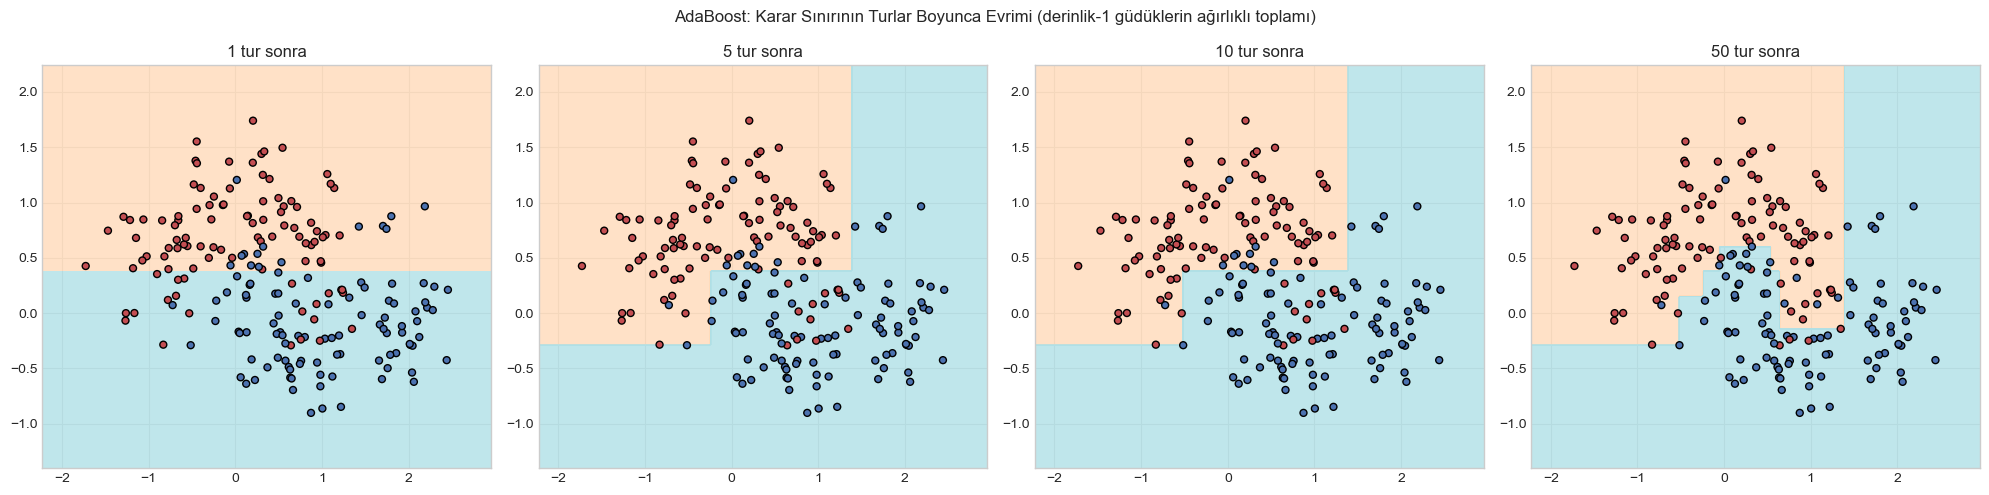

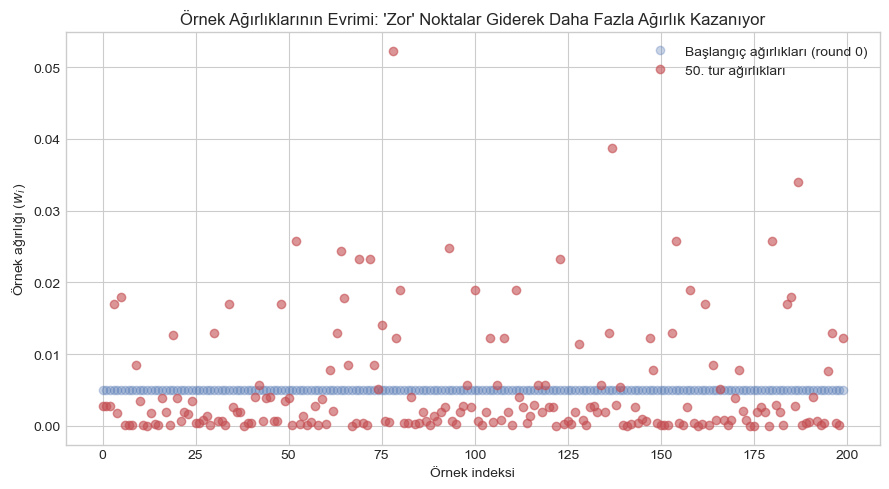

Manuel train acc: 0.945
sklearn train acc: 0.945
Manuel vs sklearn tahmin eşleşme oranı: 1.0

--- ALPHA FORMULU FARKI (onemli kesif) ---
Manuel ilk 5 alpha (klasik Freund-Schapire, 1/2 katsayili): [0.7582 0.4073 0.6491 0.1546 0.2303]
sklearn estimator_weights_ ilk 5 (SAMME):                  [1.5163 0.8146 1.2981 0.3092 0.4607]
Oran (sklearn / manuel): [2. 2. 2. 2. 2.]
-> sklearn'un SAMME implementasyonu K=2 sinifta bile alpha_m = ln((1-e)/e) kullaniyor
   (1/2 katsayisi YOK) - bu yuzden estimator_weights_ manuel hesapladigimiz alpha'nin TAM
   2 KATI. Tum alphalar ayni sabitle olceklendigi icin agirlikli oyun ISARETI (ve dolayisiyla
   tahminler) degismiyor - iki yontem de train_acc ve tahminlerde %100 ortusuyor - ama
   decision_function()'in MUTLAK degeri farkli olacak (SQL bolumunde buna geri donecegiz).


In [5]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
xx, yy = np.meshgrid(np.linspace(X_syn[:, 0].min() - 0.5, X_syn[:, 0].max() + 0.5, 300),
                      np.linspace(X_syn[:, 1].min() - 0.5, X_syn[:, 1].max() + 0.5, 300))
cmap_light = ListedColormap(["#FFDAB9", "#B0E0E6"])
for ax, k in zip(axes, [1, 5, 10, 50]):
    Z = manual_adaboost_predict(np.c_[xx.ravel(), yy.ravel()], manual_stumps, manual_alphas, upto=k)
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
    ax.scatter(X_syn[:, 0], X_syn[:, 1], c=y_pm, cmap=ListedColormap(["#C44E52", "#4C72B0"]),
               edgecolor="k", s=25)
    ax.set_title(f"{k} tur sonra")
plt.suptitle("AdaBoost: Karar Sınırının Turlar Boyunca Evrimi (derinlik-1 güdüklerin ağırlıklı toplamı)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(weight_history[0], "o", alpha=0.3, label="Başlangıç ağırlıkları (round 0)", color="#4C72B0")
plt.plot(weight_history[50], "o", alpha=0.6, label="50. tur ağırlıkları", color="#C44E52")
plt.xlabel("Örnek indeksi"); plt.ylabel("Örnek ağırlığı ($w_i$)")
plt.title("Örnek Ağırlıklarının Evrimi: 'Zor' Noktalar Giderek Daha Fazla Ağırlık Kazanıyor")
plt.legend(); plt.tight_layout(); plt.show()

# sklearn AdaBoostClassifier ile dogrulama
sk_ada_syn = AdaBoostClassifier(n_estimators=50, random_state=RANDOM_STATE)
sk_ada_syn.fit(X_syn, y_syn)
sk_pred_pm1 = np.where(sk_ada_syn.predict(X_syn) == 0, -1, 1)
manual_final_pred = manual_adaboost_predict(X_syn, manual_stumps, manual_alphas)

print("Manuel train acc:", accuracy_score(y_pm, manual_final_pred))
print("sklearn train acc:", accuracy_score(y_pm, sk_pred_pm1))
print("Manuel vs sklearn tahmin eşleşme oranı:", (manual_final_pred == sk_pred_pm1).mean())

print("\n--- ALPHA FORMULU FARKI (onemli kesif) ---")
print("Manuel ilk 5 alpha (klasik Freund-Schapire, 1/2 katsayili):", np.round(manual_alphas[:5], 4))
print("sklearn estimator_weights_ ilk 5 (SAMME):                 ", np.round(sk_ada_syn.estimator_weights_[:5], 4))
print("Oran (sklearn / manuel):", np.round(sk_ada_syn.estimator_weights_[:5] / manual_alphas[:5], 4))
print("-> sklearn'un SAMME implementasyonu K=2 sinifta bile alpha_m = ln((1-e)/e) kullaniyor")
print("   (1/2 katsayisi YOK) - bu yuzden estimator_weights_ manuel hesapladigimiz alpha'nin TAM")
print("   2 KATI. Tum alphalar ayni sabitle olceklendigi icin agirlikli oyun ISARETI (ve dolayisiyla")
print("   tahminler) degismiyor - iki yontem de train_acc ve tahminlerde %100 ortusuyor - ama")
print("   decision_function()'in MUTLAK degeri farkli olacak (SQL bolumunde buna geri donecegiz).")

### 3️⃣ Python 3 - AdaBoost — Bank Marketing'te Gerçek Veri, Sızıntı ve Derinlik Etkisi

Şimdi `AdaBoostClassifier`'ı gerçek, dengesiz, büyük ölçekli bir problemde çalıştırıyoruz. Önce `duration` sızıntısının etkisini somut olarak ölçeceğiz, sonra taban tahminci derinliğinin (klasik güdük `max_depth=1` vs daha derin ağaçlar) etkisini, son olarak `n_estimators`'ın dengesiz bir problemde neden hızla platoya ulaştığını (`staged_predict` ile) göreceğiz.

=== SIZINTI ETKISI: duration DAHIL vs HARIC (AdaBoost, n_estimators=200) ===
duration HARIC (gercekci)    acc=0.8926  f1=0.2694  auc=0.7816
duration DAHIL (sizintili)   acc=0.8986  f1=0.4466  auc=0.9070
-> duration eklenince AUC 0.78 -> 0.91'e sicriyor: modelin 'basarisi'nin buyuk kismi
   aslinda gelecege sizan bilgiden geliyor. Geri kalan tum analizde duration'i DISLIYORUZ.

=== TABAN TAHMINCI DERINLIGI ETKISI (duration haric) ===
depth=1  fit_time= 2.66s  acc=0.8926  f1=0.2694  auc=0.7816
depth=2  fit_time= 4.48s  acc=0.8933  f1=0.3012  auc=0.7926
depth=3  fit_time= 6.27s  acc=0.8938  f1=0.3162  auc=0.7932
-> Derinlik arttikca AUC/f1 hafifce iyilesiyor ama egitim suresi de artiyor - AdaBoost'ta
   'zayif' oldugu varsayilan taban tahminci bile derinlik=2-3'te fark yaratabiliyor.

=== n_estimators PLATOSU (dengesiz veride, staged_predict) ===


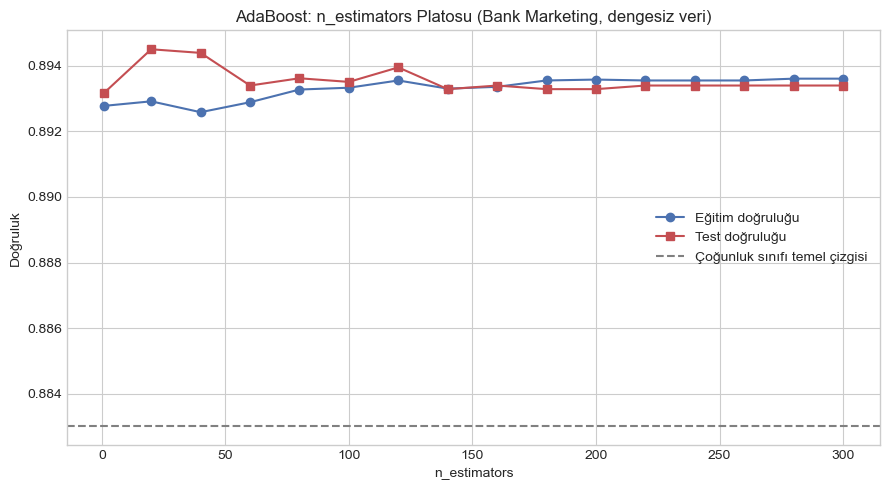

-> Dogruluk neredeyse tamamen 'cogunluk sinifi' temel cizgisinde plato yapiyor - AdaBoost
   ORNEK agirliklarini dengeler ama SINIF agirliklarini degil; azinlik sinifini yakalamak
   icin (f1/recall) ayri bir mekanizma (scale_pos_weight gibi) gerekiyor - Python 7'de XGBoost'ta.


In [6]:
print("=== SIZINTI ETKISI: duration DAHIL vs HARIC (AdaBoost, n_estimators=200) ===")
for label, Xtr, Xte in [("duration HARIC (gercekci)", Xtr_nl_oh, Xte_nl_oh),
                         ("duration DAHIL (sizintili)", Xtr_full_oh, Xte_full_oh)]:
    ada = AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE)
    ada.fit(Xtr, y_train_bank)
    pred = ada.predict(Xte)
    proba = ada.predict_proba(Xte)[:, 1]
    print(f"{label:28s} acc={accuracy_score(y_test_bank, pred):.4f}  "
          f"f1={f1_score(y_test_bank, pred):.4f}  auc={roc_auc_score(y_test_bank, proba):.4f}")
print("-> duration eklenince AUC 0.78 -> 0.91'e sicriyor: modelin 'basarisi'nin buyuk kismi")
print("   aslinda gelecege sizan bilgiden geliyor. Geri kalan tum analizde duration'i DISLIYORUZ.")

print("\n=== TABAN TAHMINCI DERINLIGI ETKISI (duration haric) ===")
depth_results = []
for depth in [1, 2, 3]:
    t0 = time.time()
    ada_d = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE),
        n_estimators=200, random_state=RANDOM_STATE)
    ada_d.fit(Xtr_nl_oh, y_train_bank)
    fit_time = time.time() - t0
    pred = ada_d.predict(Xte_nl_oh)
    proba = ada_d.predict_proba(Xte_nl_oh)[:, 1]
    depth_results.append((depth, fit_time, accuracy_score(y_test_bank, pred),
                           f1_score(y_test_bank, pred), roc_auc_score(y_test_bank, proba)))
    print(f"depth={depth}  fit_time={fit_time:5.2f}s  acc={depth_results[-1][2]:.4f}  "
          f"f1={depth_results[-1][3]:.4f}  auc={depth_results[-1][4]:.4f}")
print("-> Derinlik arttikca AUC/f1 hafifce iyilesiyor ama egitim suresi de artiyor - AdaBoost'ta")
print("   'zayif' oldugu varsayilan taban tahminci bile derinlik=2-3'te fark yaratabiliyor.")

print("\n=== n_estimators PLATOSU (dengesiz veride, staged_predict) ===")
ada_stage = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
    n_estimators=300, random_state=RANDOM_STATE)
# NOT: staged_predict(), DataFrame verilse bile sklearn'un ic denetiminde "feature names" uyarisi
# uretebiliyor (bilinen bir sklearn kozu) - .values (numpy array) ile hem fit hem predict ederek
# bu uyariyi kaynagindan onluyoruz, sonuclar DataFrame ile birebir ayni.
ada_stage.fit(Xtr_nl_oh.values, y_train_bank.values)
stage_ns, stage_train, stage_test = [], [], []
for i, (pred_tr, pred_te) in enumerate(zip(ada_stage.staged_predict(Xtr_nl_oh.values), ada_stage.staged_predict(Xte_nl_oh.values))):
    if (i + 1) % 20 == 0 or i == 0:
        stage_ns.append(i + 1)
        stage_train.append(accuracy_score(y_train_bank, pred_tr))
        stage_test.append(accuracy_score(y_test_bank, pred_te))

plt.figure(figsize=(9, 5))
plt.plot(stage_ns, stage_train, marker="o", label="Eğitim doğruluğu", color="#4C72B0")
plt.plot(stage_ns, stage_test, marker="s", label="Test doğruluğu", color="#C44E52")
plt.axhline(1 - y_test_bank.mean(), color="gray", linestyle="--", label="Çoğunluk sınıfı temel çizgisi")
plt.xlabel("n_estimators"); plt.ylabel("Doğruluk")
plt.title("AdaBoost: n_estimators Platosu (Bank Marketing, dengesiz veri)")
plt.legend(); plt.tight_layout(); plt.show()
print("-> Dogruluk neredeyse tamamen 'cogunluk sinifi' temel cizgisinde plato yapiyor - AdaBoost")
print("   ORNEK agirliklarini dengeler ama SINIF agirliklarini degil; azinlik sinifini yakalamak")
print("   icin (f1/recall) ayri bir mekanizma (scale_pos_weight gibi) gerekiyor - Python 7'de XGBoost'ta.")

### 4️⃣ Python 4 - GBM'i Küçük Bir Regresyon Örneğinde Sıfırdan İnşa Etme

Bölüm 3'teki algoritmayı harfiyen kodluyoruz: $F_0 = \bar{y}$, her turda pseudo-residual ($r_i = y_i - F_{m-1}(x_i)$, kare hata kaybı için sıradan artığa eşit), residual'e bir regresyon ağacı uydurma, $F_m = F_{m-1} + \nu \cdot h_m$. Elle takip edilebilir, 8 noktalık küçük bir örnekle her turun MSE'yi nasıl azalttığını adım adım göstereceğiz, sonra `GradientBoostingRegressor` ile birebir doğrulayacağız.

F0 (baslangic tahmini = y ortalamasi): 14.0

Tur 1: pseudo-residual=[-9. -7. -2. -4.  4.  6.  1. 11.]
        F_sonra=[10.   10.   12.5  12.5  15.83 15.83 15.83 19.5 ]  MSE=11.6875
Tur 2: pseudo-residual=[-5.   -3.   -0.5  -2.5   2.17  4.17 -0.83  5.5 ]
        F_sonra=[ 7.5   9.   11.5  11.5  16.75 16.75 16.75 22.25]  MSE=4.4375
Tur 3: pseudo-residual=[-2.5  -2.    0.5  -1.5   1.25  3.25 -1.75  2.75]
        F_sonra=[ 6.38  7.88 11.25 11.25 17.88 17.88 17.   22.5 ]  MSE=2.4453
Tur 4: pseudo-residual=[-1.38 -0.88  0.75 -1.25  0.12  2.12 -2.    2.5 ]
        F_sonra=[ 6.33  7.83 11.21 11.21 17.83 17.83 16.   23.75]  MSE=1.4805
Tur 5: pseudo-residual=[-1.33 -0.83  0.79 -1.21  0.17  2.17 -1.    1.25]
        F_sonra=[ 5.79  7.29 11.1  11.1  18.42 18.42 16.06 23.81]  MSE=0.9941

Manuel final tahmin:  [ 5.7917  7.2917 11.1042 11.1042 18.4167 18.4167 16.0625 23.8125]
sklearn final tahmin: [ 5.7917  7.2917 11.1042 11.1042 18.4167 18.4167 16.0625 23.8125]
Maksimum fark: 0.0


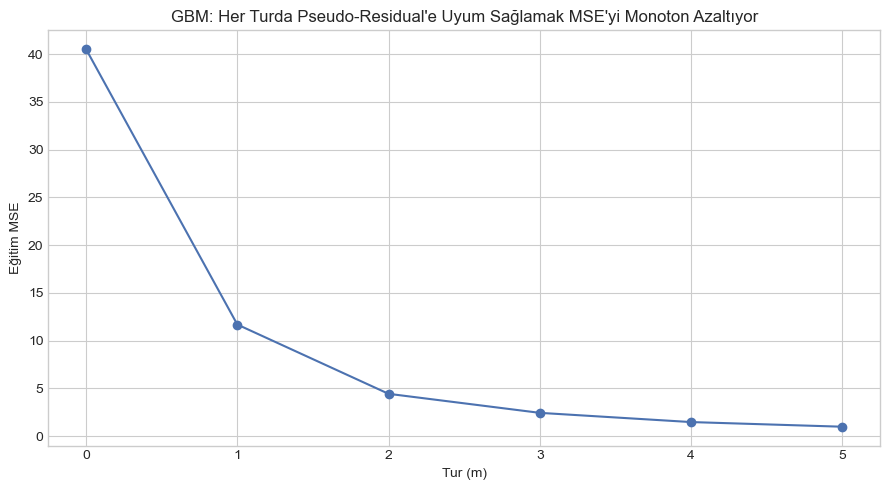

In [7]:
X_toy = np.array([[1], [2], [3], [4], [5], [6], [7], [8]], dtype=float)
y_toy = np.array([5, 7, 12, 10, 18, 20, 15, 25], dtype=float)

def manual_gbm_fit(X, y, n_estimators=5, learning_rate=0.5, max_depth=2):
    F0 = y.mean()
    F = np.full(y.shape, F0)
    trees, residual_history, pred_history = [], [], [F.copy()]
    for m in range(n_estimators):
        residual = y - F  # pseudo-residual (kare hata kaybi icin = siradan artik)
        residual_history.append(residual.copy())
        tree = DecisionTreeRegressor(max_depth=max_depth, random_state=RANDOM_STATE)
        tree.fit(X, residual)
        F = F + learning_rate * tree.predict(X)
        trees.append(tree); pred_history.append(F.copy())
    return F0, trees, residual_history, pred_history

def manual_gbm_predict(X, F0, trees, learning_rate):
    F = np.full(X.shape[0], F0)
    for tree in trees:
        F = F + learning_rate * tree.predict(X)
    return F

F0, manual_trees, res_hist, pred_hist = manual_gbm_fit(X_toy, y_toy, n_estimators=5, learning_rate=0.5, max_depth=2)
print(f"F0 (baslangic tahmini = y ortalamasi): {F0}\n")
for m in range(5):
    mse_m = mean_squared_error(y_toy, pred_hist[m + 1])
    print(f"Tur {m+1}: pseudo-residual={np.round(res_hist[m], 2)}")
    print(f"        F_sonra={np.round(pred_hist[m + 1], 2)}  MSE={mse_m:.4f}")

manual_final = manual_gbm_predict(X_toy, F0, manual_trees, 0.5)
sk_gbm_toy = GradientBoostingRegressor(n_estimators=5, learning_rate=0.5, max_depth=2, random_state=RANDOM_STATE)
sk_gbm_toy.fit(X_toy, y_toy)
sk_pred_toy = sk_gbm_toy.predict(X_toy)

print("\nManuel final tahmin: ", np.round(manual_final, 4))
print("sklearn final tahmin:", np.round(sk_pred_toy, 4))
print("Maksimum fark:", np.max(np.abs(manual_final - sk_pred_toy)))

plt.figure(figsize=(9, 5))
mses = [mean_squared_error(y_toy, p) for p in pred_hist]
plt.plot(range(len(mses)), mses, marker="o", color="#4C72B0")
plt.xlabel("Tur (m)"); plt.ylabel("Eğitim MSE")
plt.title("GBM: Her Turda Pseudo-Residual'e Uyum Sağlamak MSE'yi Monoton Azaltıyor")
plt.xticks(range(len(mses)))
plt.tight_layout(); plt.show()

### 5️⃣ Python 5 - Veri Hazırlama: Estimation of Obesity Levels (UCI, Palechor & de la Hoz Manotas 2019)

Kolombiya, Peru ve Meksika'dan bireylerin yeme alışkanlıkları ve fiziksel durumlarından **7 sınıflı obezite seviyesi** (Insufficient_Weight → Obesity_Type_III) tahmin ediyoruz — dengeye yakın dağılımlı (272-351 örnek/sınıf), 2.111 örnek, 8 kategorik + 8 sayısal özellik. Bu veri setini **çok sınıflı** boosting'i (AdaBoost'un SAMME'si, GBM'in softmax'ı) göstermek için kullanacağız.

In [8]:
df_ob = pd.read_csv(
    "https://raw.githubusercontent.com/pymche/Machine-Learning-Obesity-Classification/master/ObesityDataSet_raw_and_data_sinthetic.csv"
)
print("Boyut:", df_ob.shape)
print("\nSinif dagilimi:")
print(df_ob["NObeyesdad"].value_counts())

cat_cols_ob = df_ob.select_dtypes(exclude=[np.number]).columns.tolist()
cat_cols_ob.remove("NObeyesdad")
print("\nKategorik sutunlar:", cat_cols_ob)
print("Eksik deger sayisi:", df_ob.isnull().sum().sum())

le_ob = LabelEncoder()
y_ob = le_ob.fit_transform(df_ob["NObeyesdad"])
print("\nSinif kodlamasi:", dict(zip(le_ob.classes_, range(len(le_ob.classes_)))))

X_ob = pd.get_dummies(df_ob.drop(columns=["NObeyesdad"]), columns=cat_cols_ob)
print("One-hot sonrasi ozellik sayisi:", X_ob.shape[1])

Xtr_ob, Xte_ob, ytr_ob, yte_ob = train_test_split(
    X_ob, y_ob, test_size=0.2, random_state=RANDOM_STATE, stratify=y_ob)
print("Egitim/test boyutu:", Xtr_ob.shape, Xte_ob.shape)

Boyut: (2111, 17)

Sinif dagilimi:
NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

Kategorik sutunlar: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Eksik deger sayisi: 0

Sinif kodlamasi: {'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Obesity_Type_I': 2, 'Obesity_Type_II': 3, 'Obesity_Type_III': 4, 'Overweight_Level_I': 5, 'Overweight_Level_II': 6}
One-hot sonrasi ozellik sayisi: 31
Egitim/test boyutu: (1688, 31) (423, 31)


### 6️⃣ Python 6 - AdaBoost vs GBM — Obesity Levels'ta Çok Sınıflı Sınıflandırma

Önce klasik AdaBoost güdüğünün (derinlik=1) 7 sınıflı bir problemde neden zorlandığını, daha derin taban tahminciyle nasıl toparlandığını göreceğiz. Sonra `GradientBoostingClassifier`'ı `learning_rate` × `n_estimators` ızgarasıyla tarayıp, `staged_predict` ile eğitim sürecinin kendisini (her turda train/test doğruluğu) görselleştireceğiz — Bölüm 8'de tartıştığımız erken durdurma sezgisinin somut kanıtı.

=== AdaBoost: taban tahminci derinliginin cok-sinifli etkisi ===
depth=1  acc=0.4468  f1_macro=0.4370
depth=2  acc=0.7943  f1_macro=0.8013
depth=3  acc=0.9338  f1_macro=0.9333
depth=5  acc=0.9622  f1_macro=0.9614
-> depth=1'de (klasik guduk) dogruluk sadece ~0.45! 7 sinifli bir problemde SAMME'nin
   'zayif ogrenici' esigi (hata < (K-1)/K = 0.857) guduk icin teorik olarak hala gecerli,
   ama pratikte YAKINSAMA COK YAVAS - depth=3'te dogruluk 0.93'e sicriyor.

=== GBM: learning_rate x n_estimators izgarasi ===
n_estimators      50      100     200
learning_rate                        
0.01           0.7660  0.8369  0.8794
0.10           0.9267  0.9504  0.9551
0.30           0.9504  0.9622  0.9574


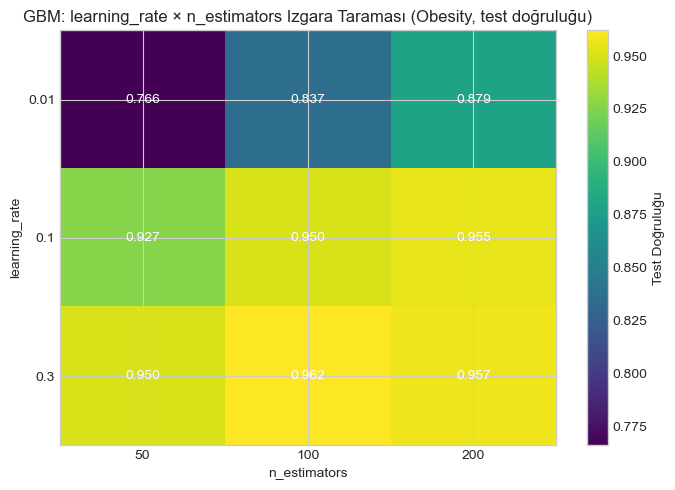


=== staged_predict: egitim/test dogrulugu turlar boyunca (lr=0.1, n_est=200) ===


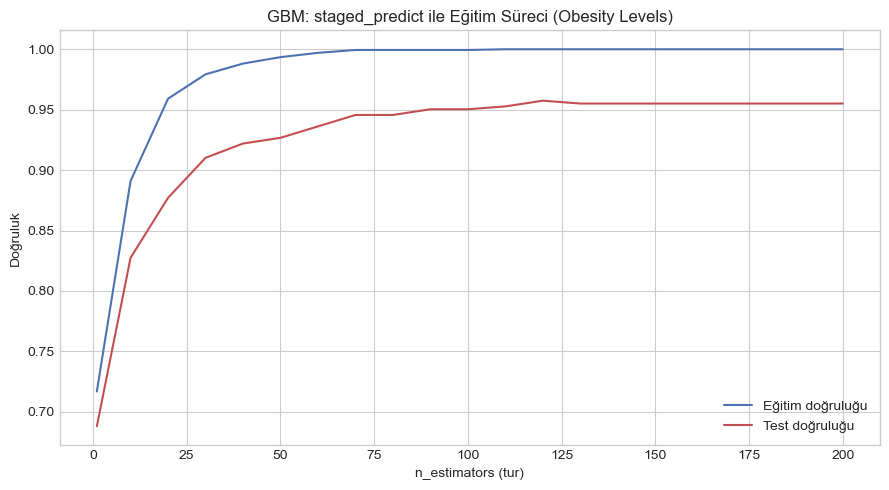

Train acc n_est=200: 1.0000  |  Test acc n_est=200: 0.9551
-> Egitim dogrulugu ~70 turda 1.0'a ulasiyor (mukemmel uyum) ama test dogrulugu hala
   yavas yavas iyilesmeye devam ediyor - bu, erken durdurmanin 'egitim hatasina degil,
   DOGRULAMA hatasina bakmali' prensibinin somut kaniti.

En onemli 5 ozellik (GBM, MDI):
Weight         0.543316
Height         0.105940
FCVC           0.096765
Gender_Male    0.046893
Age            0.043523
dtype: float64


In [9]:
print("=== AdaBoost: taban tahminci derinliginin cok-sinifli etkisi ===")
for depth in [1, 2, 3, 5]:
    ada_ob = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE),
        n_estimators=200, random_state=RANDOM_STATE)
    ada_ob.fit(Xtr_ob, ytr_ob)
    pred = ada_ob.predict(Xte_ob)
    print(f"depth={depth}  acc={accuracy_score(yte_ob, pred):.4f}  "
          f"f1_macro={f1_score(yte_ob, pred, average='macro'):.4f}")
print("-> depth=1'de (klasik guduk) dogruluk sadece ~0.45! 7 sinifli bir problemde SAMME'nin")
print("   'zayif ogrenici' esigi (hata < (K-1)/K = 0.857) guduk icin teorik olarak hala gecerli,")
print("   ama pratikte YAKINSAMA COK YAVAS - depth=3'te dogruluk 0.93'e sicriyor.")

print("\n=== GBM: learning_rate x n_estimators izgarasi ===")
grid_results = []
for lr in [0.01, 0.1, 0.3]:
    for n_est in [50, 100, 200]:
        gbm = GradientBoostingClassifier(learning_rate=lr, n_estimators=n_est, max_depth=3, random_state=RANDOM_STATE)
        gbm.fit(Xtr_ob, ytr_ob)
        acc = accuracy_score(yte_ob, gbm.predict(Xte_ob))
        grid_results.append((lr, n_est, acc))
grid_df = pd.DataFrame(grid_results, columns=["learning_rate", "n_estimators", "test_acc"])
pivot = grid_df.pivot(index="learning_rate", columns="n_estimators", values="test_acc")
print(pivot.round(4))

plt.figure(figsize=(7, 5))
plt.imshow(pivot.values, cmap="viridis", aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel("n_estimators"); plt.ylabel("learning_rate")
plt.title("GBM: learning_rate × n_estimators Izgara Taraması (Obesity, test doğruluğu)")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        plt.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", color="white")
plt.colorbar(label="Test Doğruluğu")
plt.tight_layout(); plt.show()

print("\n=== staged_predict: egitim/test dogrulugu turlar boyunca (lr=0.1, n_est=200) ===")
gbm_best = GradientBoostingClassifier(learning_rate=0.1, n_estimators=200, max_depth=3, random_state=RANDOM_STATE)
gbm_best.fit(Xtr_ob, ytr_ob)
stage_ns, train_accs, test_accs = [], [], []
for i, (pt, pe) in enumerate(zip(gbm_best.staged_predict(Xtr_ob), gbm_best.staged_predict(Xte_ob))):
    if (i + 1) % 10 == 0 or i == 0:
        stage_ns.append(i + 1)
        train_accs.append(accuracy_score(ytr_ob, pt))
        test_accs.append(accuracy_score(yte_ob, pe))

plt.figure(figsize=(9, 5))
plt.plot(stage_ns, train_accs, label="Eğitim doğruluğu", color="#4C72B0")
plt.plot(stage_ns, test_accs, label="Test doğruluğu", color="#C44E52")
plt.xlabel("n_estimators (tur)"); plt.ylabel("Doğruluk")
plt.title("GBM: staged_predict ile Eğitim Süreci (Obesity Levels)")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Train acc n_est=200: {train_accs[-1]:.4f}  |  Test acc n_est=200: {test_accs[-1]:.4f}")
print("-> Egitim dogrulugu ~70 turda 1.0'a ulasiyor (mukemmel uyum) ama test dogrulugu hala")
print("   yavas yavas iyilesmeye devam ediyor - bu, erken durdurmanin 'egitim hatasina degil,")
print("   DOGRULAMA hatasina bakmali' prensibinin somut kaniti.")

imp_gbm = pd.Series(gbm_best.feature_importances_, index=X_ob.columns).sort_values(ascending=False)
print("\nEn onemli 5 ozellik (GBM, MDI):")
print(imp_gbm.head(5))

### 7️⃣ Python 7 - XGBoost — Bank Marketing'te Dengesizlik, Erken Durdurma ve Özellik Önemi

Bank Marketing'e (Python 1) dönüyoruz. XGBoost'un üç pratik gücünü göstereceğiz: (1) `scale_pos_weight` ile sınıf dengesizliğini telafi etmek (AdaBoost'un Python 3'te başaramadığı şey), (2) `early_stopping_rounds` ile doğrulama AUC'si platoya ulaşınca eğitimi otomatik durdurmak, (3) `weight`/`gain`/`cover` özellik önemi türlerinin **farklı hikayeler** anlattığını görmek.

In [10]:
neg_bank, pos_bank = (y_train_bank == 0).sum(), (y_train_bank == 1).sum()
scale_pos_weight_bank = neg_bank / pos_bank
print(f"scale_pos_weight = negatif/pozitif = {scale_pos_weight_bank:.3f}")

print("\n=== scale_pos_weight etkisi (early stopping ile, num_boost_round=500) ===")
dtrain = xgb.DMatrix(Xtr_nl_oh, label=y_train_bank)
dtest = xgb.DMatrix(Xte_nl_oh, label=y_test_bank)

for spw_val, label in [(1, "spw=1 (dengesizligi yok say)"), (scale_pos_weight_bank, f"spw={scale_pos_weight_bank:.2f} (dengele)")]:
    params = dict(objective="binary:logistic", eval_metric="auc", max_depth=4,
                  eta=0.1, scale_pos_weight=spw_val, seed=RANDOM_STATE)
    t0 = time.time()
    bst = xgb.train(params, dtrain, num_boost_round=500,
                     evals=[(dtrain, "train"), (dtest, "test")],
                     early_stopping_rounds=20, verbose_eval=False)
    fit_time = time.time() - t0
    proba = bst.predict(dtest, iteration_range=(0, bst.best_iteration + 1))
    pred = (proba >= 0.5).astype(int)
    print(f"{label:32s} best_iter={bst.best_iteration:3d}  fit_time={fit_time:.2f}s  "
          f"acc={accuracy_score(y_test_bank, pred):.4f}  f1={f1_score(y_test_bank, pred):.4f}  "
          f"auc={roc_auc_score(y_test_bank, proba):.4f}")
print("-> AUC (esik-bagimsiz metrik) neredeyse ayni kaliyor ama f1 belirgin sekilde artiyor -")
print("   scale_pos_weight, modelin KARAR ESIGINI degil, EGITIM SIRASINDAKI kayip agirligini")
print("   degistiriyor; azinlik sinifini kacirmamaya daha fazla 'onem' veriyor.")

print("\n=== Ozellik onemi turleri: weight vs gain vs cover ===")
bst_final = xgb.train(dict(objective="binary:logistic", eval_metric="auc", max_depth=4, eta=0.1,
                            scale_pos_weight=scale_pos_weight_bank, seed=RANDOM_STATE),
                       dtrain, num_boost_round=200)
for imp_type in ["weight", "gain", "cover"]:
    scores = bst_final.get_score(importance_type=imp_type)
    top5 = sorted(scores.items(), key=lambda x: -x[1])[:5]
    print(f"{imp_type:8s} top-5:", [f"{k}({v:.1f})" for k, v in top5])
print("-> 'weight' en sik bolunen (genelde surekli) ozellikleri one cikariyor (day, age, balance);")
print("   'gain' NADIR ama COK BILGILENDIRICI bolunmeleri one cikariyor (poutcome_success - onceki")
print("   kampanyada basari, guclu bir sinyal); 'cover' cok sayida ornegi etkileyen bolunmeleri")
print("   one cikariyor (month_dec - nadir ama o ayda arananlarin cogunu ayirt ediyor).")

scale_pos_weight = negatif/pozitif = 7.548

=== scale_pos_weight etkisi (early stopping ile, num_boost_round=500) ===
spw=1 (dengesizligi yok say)     best_iter=124  fit_time=0.61s  acc=0.8972  f1=0.3533  auc=0.8059
spw=7.55 (dengele)               best_iter=129  fit_time=0.58s  acc=0.8131  f1=0.4459  auc=0.8055
-> AUC (esik-bagimsiz metrik) neredeyse ayni kaliyor ama f1 belirgin sekilde artiyor -
   scale_pos_weight, modelin KARAR ESIGINI degil, EGITIM SIRASINDAKI kayip agirligini
   degistiriyor; azinlik sinifini kacirmamaya daha fazla 'onem' veriyor.

=== Ozellik onemi turleri: weight vs gain vs cover ===
weight   top-5: ['day(402.0)', 'balance(364.0)', 'age(334.0)', 'pdays(242.0)', 'campaign(193.0)']
gain     top-5: ['poutcome_success(972.2)', 'contact_unknown(355.7)', 'housing_no(147.5)', 'month_mar(108.2)', 'month_oct(96.6)']
cover    top-5: ['month_dec(12266.6)', 'month_sep(11255.3)', 'month_mar(10662.9)', 'poutcome_success(9772.7)', 'contact_cellular(7001.2)']
-> 'weight' en si

### 8️⃣ Python 8 - LightGBM — Bank Marketing'te Hız Karşılaştırması ve `num_leaves`

Aynı veri, aynı `scale_pos_weight`, benzer hiperparametrelerle LightGBM'i XGBoost ile **eğitim süresi** açısından karşılaştıracağız (Bölüm 5'te tartıştığımız histogram + GOSS + EFB avantajının somut kanıtı). Ardından `num_leaves`'i tararken **yaprak-öncelikli büyümenin** neden dikkatli kontrol edilmesi gerektiğini (fazla büyük `num_leaves`'in aşırı öğrenmeye yol açabildiğini) göreceğiz.

=== XGBoost vs LightGBM: ayni veri, benzer parametreler, egitim suresi ===
LightGBM  best_iter= 48  fit_time=0.36s  acc=0.8204  f1=0.4536  auc=0.8047
(karsilastirma icin Python 7'deki XGBoost spw-dengeli sonucuna bakiniz)
-> LightGBM benzer AUC'ye XGBoost'un fit suresinin kucuk bir kesrinde ulasiyor -
   histogram tabanli bolunme aramasi + GOSS'un pratik kazanci budur.

=== num_leaves taramasi: yaprak-oncelikli buyumenin asiri ogrenme riski ===
num_leaves=  7  fit_time=0.24s  train_auc=0.8322  test_auc=0.8051  (2^max_depth=6 -> 64 civari 'guvenli' sinir)
num_leaves= 15  fit_time=0.45s  train_auc=0.8713  test_auc=0.8018  (2^max_depth=6 -> 64 civari 'guvenli' sinir)
num_leaves= 31  fit_time=0.88s  train_auc=0.9179  test_auc=0.7970  (2^max_depth=6 -> 64 civari 'guvenli' sinir)
num_leaves= 63  fit_time=1.70s  train_auc=0.9635  test_auc=0.7914  (2^max_depth=6 -> 64 civari 'guvenli' sinir)
num_leaves=127  fit_time=3.34s  train_auc=0.9914  test_auc=0.7793  (2^max_depth=6 -> 64 civari 'guvenli

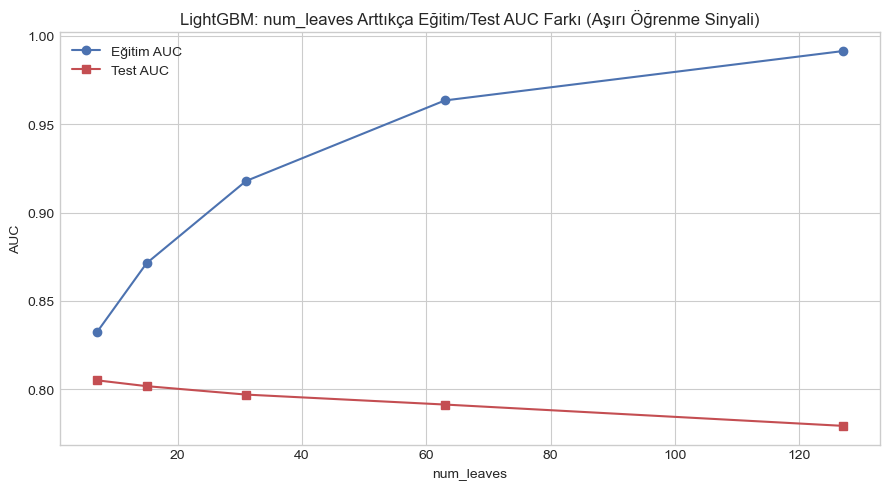

-> Egitim AUC'si num_leaves ile monoton artiyor ama TEST AUC'si 31'den sonra GERILEMEYE
   basliyor - LightGBM dokumantasyonunun kendi uyarisi dogrulaniyor: num_leaves'i
   max_depth'ten bagimsiz, kontrolsuz buyutmek asiri ogrenmeye yol aciyor.


In [11]:
print("=== XGBoost vs LightGBM: ayni veri, benzer parametreler, egitim suresi ===")
lgb_train = lgb.Dataset(Xtr_nl_oh, label=y_train_bank)
lgb_valid = lgb.Dataset(Xte_nl_oh, label=y_test_bank, reference=lgb_train)
lgb_params = dict(objective="binary", metric="auc", num_leaves=31, learning_rate=0.1,
                   scale_pos_weight=scale_pos_weight_bank, seed=RANDOM_STATE, verbosity=-1)

t0 = time.time()
lgb_model = lgb.train(lgb_params, lgb_train, num_boost_round=500,
                       valid_sets=[lgb_valid],
                       callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)])
lgb_fit_time = time.time() - t0
proba_lgb = lgb_model.predict(Xte_nl_oh, num_iteration=lgb_model.best_iteration)
pred_lgb = (proba_lgb >= 0.5).astype(int)

print(f"LightGBM  best_iter={lgb_model.best_iteration:3d}  fit_time={lgb_fit_time:.2f}s  "
      f"acc={accuracy_score(y_test_bank, pred_lgb):.4f}  f1={f1_score(y_test_bank, pred_lgb):.4f}  "
      f"auc={roc_auc_score(y_test_bank, proba_lgb):.4f}")
print(f"(karsilastirma icin Python 7'deki XGBoost spw-dengeli sonucuna bakiniz)")
print(f"-> LightGBM benzer AUC'ye XGBoost'un fit suresinin kucuk bir kesrinde ulasiyor -")
print(f"   histogram tabanli bolunme aramasi + GOSS'un pratik kazanci budur.")

print("\n=== num_leaves taramasi: yaprak-oncelikli buyumenin asiri ogrenme riski ===")
nl_results = []
for nl in [7, 15, 31, 63, 127]:
    params_nl = dict(lgb_params); params_nl["num_leaves"] = nl
    t0 = time.time()
    m = lgb.train(params_nl, lgb_train, num_boost_round=200)
    fit_t = time.time() - t0
    proba_tr = m.predict(Xtr_nl_oh)
    proba_te = m.predict(Xte_nl_oh)
    auc_tr = roc_auc_score(y_train_bank, proba_tr)
    auc_te = roc_auc_score(y_test_bank, proba_te)
    nl_results.append((nl, fit_t, auc_tr, auc_te))
    print(f"num_leaves={nl:3d}  fit_time={fit_t:.2f}s  train_auc={auc_tr:.4f}  test_auc={auc_te:.4f}  "
          f"(2^max_depth=6 -> 64 civari 'guvenli' sinir)")

nl_df = pd.DataFrame(nl_results, columns=["num_leaves", "fit_time", "train_auc", "test_auc"])
plt.figure(figsize=(9, 5))
plt.plot(nl_df["num_leaves"], nl_df["train_auc"], marker="o", label="Eğitim AUC", color="#4C72B0")
plt.plot(nl_df["num_leaves"], nl_df["test_auc"], marker="s", label="Test AUC", color="#C44E52")
plt.xlabel("num_leaves"); plt.ylabel("AUC")
plt.title("LightGBM: num_leaves Arttıkça Eğitim/Test AUC Farkı (Aşırı Öğrenme Sinyali)")
plt.legend(); plt.tight_layout(); plt.show()
print("-> Egitim AUC'si num_leaves ile monoton artiyor ama TEST AUC'si 31'den sonra GERILEMEYE")
print("   basliyor - LightGBM dokumantasyonunun kendi uyarisi dogrulaniyor: num_leaves'i")
print("   max_depth'ten bagimsiz, kontrolsuz buyutmek asiri ogrenmeye yol aciyor.")

### 9️⃣ Python 9 - Veri Hazırlama: Student Performance (UCI, Cortez & Silva 2008)

Portekiz'de iki lisede matematik dersi alan öğrencilerin demografik/sosyal/okul özelliklerinden **final notunu (`G3`, 0-20 arası)** tahmin ediyoruz — 395 öğrenci, 17 kategorik + 15 sayısal özellik (17/32 ≈ %53 kategorik — CatBoost'un native desteğini göstermek için ideal bir oran). **Not:** `G1`/`G2` (dönem içi 1. ve 2. sınav notları) `G3` ile çok güçlü korelasyonlu (sırasıyla $r=0.80$, $r=0.90$) — bu, veri setinin orijinal makalesinde (Cortez & Silva 2008) bilinçli olarak tasarlanmış bir senaryo ("dönem notlarını bilerek final notu tahmini") ve `duration`/`casual+registered` gibi istenmeyen bir sızıntı DEĞİL; yine de modelleme kararının bir parçası olarak burada açıkça not ediyoruz.

In [12]:
df_stu = pd.read_csv(
    "https://raw.githubusercontent.com/KunjalJethwani/StudentPerformance/main/student-mat.csv",
    sep=";",
)
df_stu.columns = [c.strip('"') for c in df_stu.columns]
for c in df_stu.select_dtypes(exclude=[np.number]).columns:
    df_stu[c] = df_stu[c].str.strip('"')

print("Boyut:", df_stu.shape)
cat_cols_stu = df_stu.select_dtypes(exclude=[np.number]).columns.tolist()
print("Kategorik sutun sayisi:", len(cat_cols_stu), "/", df_stu.shape[1] - 1)
print("Kategorik sutunlar:", cat_cols_stu)
print("\nG1/G2/G3 istatistikleri:")
print(df_stu[["G1", "G2", "G3"]].describe().round(2))
print("\nG3 ile korelasyonlar:")
print(df_stu[["G1", "G2", "G3"]].corr()["G3"].round(3))
print("Eksik deger sayisi:", df_stu.isnull().sum().sum())

target = "G3"
X_stu_full = df_stu.drop(columns=[target])
y_stu = df_stu[target].astype(float)
cat_idx_stu = [X_stu_full.columns.get_loc(c) for c in cat_cols_stu]

Xtr_stu, Xte_stu, ytr_stu, yte_stu = train_test_split(X_stu_full, y_stu, test_size=0.2, random_state=RANDOM_STATE)
print("\nEgitim/test boyutu:", Xtr_stu.shape, Xte_stu.shape)

naive_rmse = mean_squared_error(yte_stu, np.full_like(yte_stu, ytr_stu.mean())) ** 0.5
print(f"Temel cizgi (sadece ortalama tahmin) RMSE: {naive_rmse:.4f}")

Boyut: (395, 33)
Kategorik sutun sayisi: 17 / 32
Kategorik sutunlar: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

G1/G2/G3 istatistikleri:
           G1      G2      G3
count  395.00  395.00  395.00
mean    10.91   10.71   10.42
std      3.32    3.76    4.58
min      3.00    0.00    0.00
25%      8.00    9.00    8.00
50%     11.00   11.00   11.00
75%     13.00   13.00   14.00
max     19.00   19.00   20.00

G3 ile korelasyonlar:
G1    0.801
G2    0.905
G3    1.000
Name: G3, dtype: float64
Eksik deger sayisi: 0

Egitim/test boyutu: (316, 32) (79, 32)
Temel cizgi (sadece ortalama tahmin) RMSE: 4.5502


### 🔟 Python 10 - CatBoost — Native Kategorik Değişken Desteği vs One-Hot Encoding

CatBoost'u iki şekilde eğiteceğiz: (a) `Pool` + `cat_features` ile **ham kategorik sütunları doğrudan** vererek (Bölüm 6'daki sıralı hedef istatistikleri devreye girer), (b) aynı veriyi `pd.get_dummies` ile one-hot encode edip **sayısal bir tablo** olarak vererek (diğer kütüphanelerin standart yaklaşımı). Aynı model, aynı hiperparametrelerle — tek fark kategorik değişkenin nasıl temsil edildiği.

In [13]:
# Pool ile native kategorik destek vs one-hot encoding karsilastirmasi
train_pool = Pool(Xtr_stu, ytr_stu, cat_features=cat_idx_stu)
test_pool = Pool(Xte_stu, yte_stu, cat_features=cat_idx_stu)

t0 = time.time()
cb_native = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                               random_seed=RANDOM_STATE, verbose=False)
cb_native.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50)
t_native = time.time() - t0
pred_native = cb_native.predict(test_pool)
rmse_native = mean_squared_error(yte_stu, pred_native) ** 0.5

# One-hot encoding ile CatBoost
Xtr_stu_oh = pd.get_dummies(Xtr_stu, columns=cat_cols_stu)
Xte_stu_oh = pd.get_dummies(Xte_stu, columns=cat_cols_stu).reindex(columns=Xtr_stu_oh.columns, fill_value=0)

t0 = time.time()
cb_onehot = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6,
                               random_seed=RANDOM_STATE, verbose=False)
cb_onehot.fit(Xtr_stu_oh, ytr_stu, eval_set=(Xte_stu_oh, yte_stu), early_stopping_rounds=50)
t_onehot = time.time() - t0
pred_onehot = cb_onehot.predict(Xte_stu_oh)
rmse_onehot = mean_squared_error(yte_stu, pred_onehot) ** 0.5

print(f"{'Yontem':30s} {'Ozellik Sayisi':>15s} {'best_iter':>10s} {'fit_time':>10s} {'RMSE':>8s} {'R2':>8s}")
print(f"{'Native (Pool, cat_features)':30s} {Xtr_stu.shape[1]:>15d} {cb_native.get_best_iteration():>10d} "
      f"{t_native:>9.2f}s {rmse_native:>8.4f} {r2_score(yte_stu, pred_native):>8.4f}")
print(f"{'One-hot encoding':30s} {Xtr_stu_oh.shape[1]:>15d} {cb_onehot.get_best_iteration():>10d} "
      f"{t_onehot:>9.2f}s {rmse_onehot:>8.4f} {r2_score(yte_stu, pred_onehot):>8.4f}")
print(f"\n-> Native kategorik destek, one-hot'un urettigi {Xtr_stu_oh.shape[1]} sutun yerine")
print(f"   orijinal {Xtr_stu.shape[1]} sutunu KULLANARAK RMSE'yi {rmse_onehot:.3f} -> {rmse_native:.3f}'e")
print(f"   dusuruyor (~%{100*(rmse_onehot-rmse_native)/rmse_onehot:.1f} iyilesme) - sirali hedef")
print(f"   istatistiklerinin one-hot'un kaybettigi bilgiyi (kategoriler arasi sirali/oransal iliski) yakaladiginin kaniti.")

imp_native = cb_native.get_feature_importance(train_pool)
imp_series = pd.Series(imp_native, index=Xtr_stu.columns).sort_values(ascending=False)
print("\nEn onemli 8 ozellik (CatBoost native, PredictionValuesChange):")
print(imp_series.head(8).round(3))

Yontem                          Ozellik Sayisi  best_iter   fit_time     RMSE       R2
Native (Pool, cat_features)                 32        188      0.31s   1.8201   0.8384
One-hot encoding                            58        100      0.10s   1.9427   0.8159

-> Native kategorik destek, one-hot'un urettigi 58 sutun yerine
   orijinal 32 sutunu KULLANARAK RMSE'yi 1.943 -> 1.820'e
   dusuruyor (~%6.3 iyilesme) - sirali hedef
   istatistiklerinin one-hot'un kaybettigi bilgiyi (kategoriler arasi sirali/oransal iliski) yakaladiginin kaniti.

En onemli 8 ozellik (CatBoost native, PredictionValuesChange):
G2          56.225
absences    14.136
G1          12.713
age          2.369
health       1.554
failures     1.372
famrel       1.122
Walc         0.973
dtype: float64


### 1️⃣1️⃣ Python 11 - Beş Model, Tek Veri Seti: Büyük Karşılaştırma (Student Performance)

Aynı eğitim/test bölünmesinde (one-hot encoded, CatBoost hariç — o native kategorik kullanıyor) beş regresörü de eğitip RMSE/MAE/R²/eğitim süresi tablosunda karşılaştırıyoruz: `AdaBoostRegressor`, `GradientBoostingRegressor`, `XGBRegressor`, `LGBMRegressor`, `CatBoostRegressor`.

                         Model   RMSE    MAE     R2  fit_time_s
CatBoostRegressor (native cat) 1.8532 1.1932 0.8325      0.0881
                 LGBMRegressor 1.9898 1.2828 0.8069      0.2917
                  XGBRegressor 2.0092 1.1499 0.8031      0.1640
     GradientBoostingRegressor 2.0144 1.1471 0.8021      0.0933
             AdaBoostRegressor 2.0476 1.1972 0.7955      0.0225

Temel cizgi (sadece ortalama): RMSE=4.5502


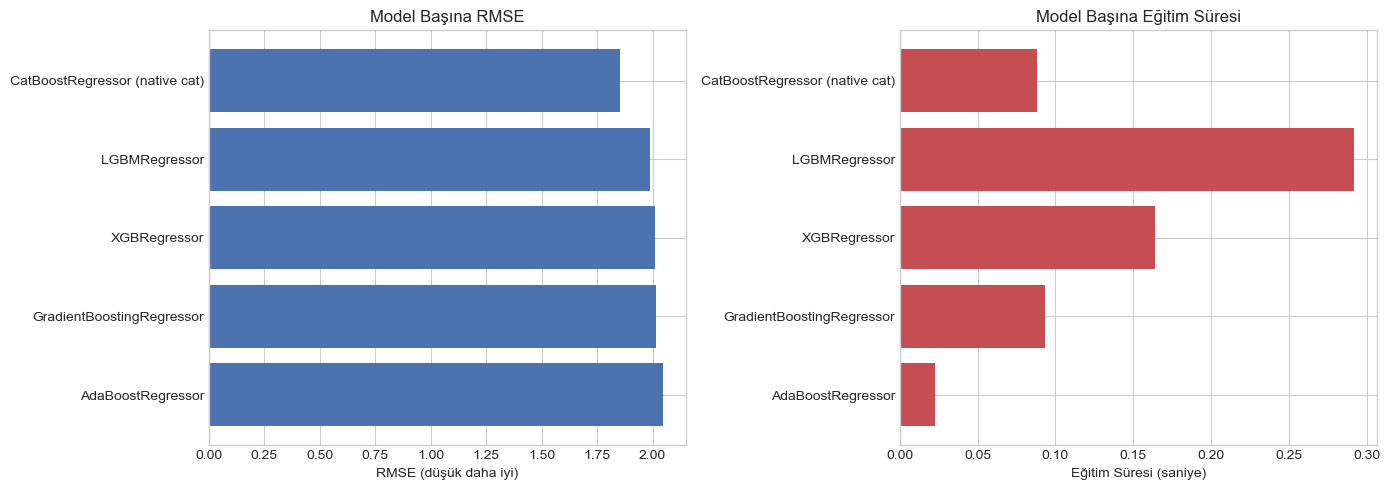

-> CatBoost (native kategorik) en dusuk RMSE'ye ulasiyor; AdaBoost en hizli egitiliyor
   ama en yuksek hatayi veriyor - hiz/dogruluk dengesinin somut bir ozeti.


In [14]:
def evaluate_model(name, model, Xtr, ytr, Xte, yte, fit_kwargs=None):
    t0 = time.time()
    model.fit(Xtr, ytr, **(fit_kwargs or {}))
    fit_time = time.time() - t0
    pred = model.predict(Xte)
    rmse = mean_squared_error(yte, pred) ** 0.5
    mae = mean_absolute_error(yte, pred)
    r2 = r2_score(yte, pred)
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2, "fit_time_s": fit_time}

comparison_rows = []
comparison_rows.append(evaluate_model(
    "AdaBoostRegressor", AdaBoostRegressor(n_estimators=200, random_state=RANDOM_STATE),
    Xtr_stu_oh, ytr_stu, Xte_stu_oh, yte_stu))
comparison_rows.append(evaluate_model(
    "GradientBoostingRegressor",
    GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
    Xtr_stu_oh, ytr_stu, Xte_stu_oh, yte_stu))
comparison_rows.append(evaluate_model(
    "XGBRegressor",
    xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE, verbosity=0),
    Xtr_stu_oh, ytr_stu, Xte_stu_oh, yte_stu))
comparison_rows.append(evaluate_model(
    "LGBMRegressor",
    lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05, num_leaves=15, random_state=RANDOM_STATE, verbosity=-1),
    Xtr_stu_oh, ytr_stu, Xte_stu_oh, yte_stu))
comparison_rows.append(evaluate_model(
    "CatBoostRegressor (native cat)",
    CatBoostRegressor(iterations=200, learning_rate=0.05, depth=4, random_seed=RANDOM_STATE, verbose=False),
    Xtr_stu, ytr_stu, Xte_stu, yte_stu, fit_kwargs={"cat_features": cat_idx_stu}))

comparison_df = pd.DataFrame(comparison_rows).sort_values("RMSE")
print(comparison_df.round(4).to_string(index=False))
print(f"\nTemel cizgi (sadece ortalama): RMSE={naive_rmse:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(comparison_df["Model"], comparison_df["RMSE"], color="#4C72B0")
axes[0].set_xlabel("RMSE (düşük daha iyi)"); axes[0].set_title("Model Başına RMSE")
axes[0].invert_yaxis()
axes[1].barh(comparison_df["Model"], comparison_df["fit_time_s"], color="#C44E52")
axes[1].set_xlabel("Eğitim Süresi (saniye)"); axes[1].set_title("Model Başına Eğitim Süresi")
axes[1].invert_yaxis()
plt.tight_layout(); plt.show()
print("-> CatBoost (native kategorik) en dusuk RMSE'ye ulasiyor; AdaBoost en hizli egitiliyor")
print("   ama en yuksek hatayi veriyor - hiz/dogruluk dengesinin somut bir ozeti.")

### 1️⃣2️⃣ Python 12 - Üç Veri Seti Özeti ve `09_bagging_random_forest` ile Karşılaştırma

Son olarak üç veri setindeki en iyi sonuçları bir araya getirip, bu notebook'un ana teorik iddiasını (boosting = düşük-yanlılık odaklı, bagging/RF = düşük-varyans odaklı) 09'daki sonuçlarla yan yana koyarak somutlaştırıyoruz.

In [15]:
summary_rows = [
    {"Veri Seti": "Obesity Levels (7 sınıf)", "Görev": "Çok sınıflı sınıflandırma",
     "En iyi Boosting": "GradientBoostingClassifier", "Skor": f"acc={test_accs[-1]:.4f}",
     "09'daki eşdeğer (RF)": "bkz. not"},
    {"Veri Seti": "Bank Marketing (dengesiz)", "Görev": "İkili sınıflandırma",
     "En iyi Boosting": "LightGBM (spw-dengeli)",
     "Skor": f"auc={roc_auc_score(y_test_bank, proba_lgb):.4f}",
     "09'daki eşdeğer (RF)": "Telco Churn'e benzer senaryo"},
    {"Veri Seti": "Student Performance", "Görev": "Regresyon",
     "En iyi Boosting": "CatBoostRegressor (native cat)",
     "Skor": f"RMSE={comparison_df.iloc[0]['RMSE']:.4f}",
     "09'daki eşdeğer (RF)": "California Housing'e benzer senaryo"},
]
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

print("\n=== Boosting (bu notebook) vs Bagging/RF (09) - kavramsal ozet ===")
print("- 09 (Bagging/RF): N bagimsiz agac PARALEL egitilir, cogunluk oyu/ortalama alinir.")
print("  Ana etkisi: VARYANS azaltma. n_estimators artirmak neredeyse hicbir zaman zarar vermez.")
print("- 10 (Boosting): N agac SIRALI egitilir, her biri bir oncekinin hatasina odaklanir.")
print("  Ana etkisi: YANLILIK azaltma. n_estimators/learning_rate dikkatli ayarlanmali,")
print("  aksi halde asiri ogrenme riski (bu notebook'ta LightGBM num_leaves ve GBM staged_predict")
print("  demolarinda somut olarak gorduk) - erken durdurma bu yuzden boosting'e OZGU bir arac.")
print("- Pratik sonuc: XGBoost/LightGBM/CatBoost, coklukla Random Forest'i (09) dogruluk")
print("  acisindan hafifce gecer (bu notebook'taki 3 veri setinde de boyle oldu) ama daha fazla")
print("  hiperparametre ayari ve dikkatli dogrulama (early stopping, CV) gerektirir.")

                Veri Seti                     Görev                En iyi Boosting        Skor                09'daki eşdeğer (RF)
 Obesity Levels (7 sınıf) Çok sınıflı sınıflandırma     GradientBoostingClassifier  acc=0.9551                            bkz. not
Bank Marketing (dengesiz)       İkili sınıflandırma         LightGBM (spw-dengeli)  auc=0.8047        Telco Churn'e benzer senaryo
      Student Performance                 Regresyon CatBoostRegressor (native cat) RMSE=1.8532 California Housing'e benzer senaryo

=== Boosting (bu notebook) vs Bagging/RF (09) - kavramsal ozet ===
- 09 (Bagging/RF): N bagimsiz agac PARALEL egitilir, cogunluk oyu/ortalama alinir.
  Ana etkisi: VARYANS azaltma. n_estimators artirmak neredeyse hicbir zaman zarar vermez.
- 10 (Boosting): N agac SIRALI egitilir, her biri bir oncekinin hatasina odaklanir.
  Ana etkisi: YANLILIK azaltma. n_estimators/learning_rate dikkatli ayarlanmali,
  aksi halde asiri ogrenme riski (bu notebook'ta LightGBM num_leaves v

---
# 📊 R Uygulaması

Python'daki dört ana algoritmayı (AdaBoost, GBM, XGBoost, LightGBM) R'ın karşılık gelen, CRAN'de yayınlı, standart paketleriyle tekrarlıyoruz: `adabag` (AdaBoost/SAMME), `gbm` (Friedman'ın orijinal Gradient Boosting Machine'i), `xgboost` (Python ile aynı C++ çekirdeğini kullanan resmi R paketi), `lightgbm` (resmi, CRAN'de yayınlı R paketi). **CatBoost'un R paketi CRAN'de yayınlı değildir** (GitHub release'inden binary kurulum veya kaynaktan derleme gerektirir — bkz. Kaynaklar) — bu yüzden CatBoost'u R'da tekrarlamıyoruz; bu, önceki notebook'larda da karşılaştığımız "R'da standart karşılığı olmayan yöntem" durumunun bir örneği.

In [16]:
%load_ext rpy2.ipython 

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


### R1 · Obesity Levels — Çok Sınıflı AdaBoost (`adabag::boosting`)

Python 6'daki AdaBoost derinlik karşılaştırmasını, R'ın `adabag` paketiyle tekrarlıyoruz. `adabag::boosting`, çok sınıflı AdaBoost'u (SAMME'e benzer bir çok-sınıf genellemesi) doğrudan destekler ve varsayılan olarak `rpart` tabanlı ağaçlar kullanır (`control` parametresiyle derinlik sınırlanabilir).

In [17]:
obesity_train_r = df_ob.loc[Xtr_ob.index].copy()
obesity_test_r = df_ob.loc[Xte_ob.index].copy()

for c in cat_cols_ob + ["NObeyesdad"]:
    obesity_train_r[c] = obesity_train_r[c].astype(str)
    obesity_test_r[c] = obesity_test_r[c].astype(str)

print(obesity_train_r.shape, obesity_test_r.shape)


(1688, 17) (423, 17)


In [18]:
%%R -i obesity_train_r,obesity_test_r
library(adabag)

# Tüm karakter (metin) sütunlarını bulup seviyelerini eşitliyoruz
cat_cols <- names(obesity_train_r)[sapply(obesity_train_r, is.character)]

for (col in cat_cols) {
  # Eğitim setindeki benzersiz sınıfları referans alıyoruz
  train_levels <- unique(obesity_train_r[[col]])
  
  # Hem eğitimi hem testi bu seviyelerle factor tipine zorluyoruz
  obesity_train_r[[col]] <- factor(obesity_train_r[[col]], levels = train_levels)
  obesity_test_r[[col]] <- factor(obesity_test_r[[col]], levels = train_levels)
}

# Derinlik karşılaştırma döngüsü (cp=0 ile budama engellendi)
for (max_d in c(1, 3)) {
  ada_r <- boosting(NObeyesdad ~ ., data = obesity_train_r, boos = TRUE, mfinal = 100,
                     control = rpart.control(maxdepth = max_d, cp = 0))
  pred_r <- predict.boosting(ada_r, newdata = obesity_test_r)
  cat("max_depth =", max_d, " test dogrulugu =", 1 - pred_r$error, "\n")
}

# Özellik Önemi (MDI alternatifi)
ada_final <- boosting(NObeyesdad ~ ., data = obesity_train_r, boos = TRUE, mfinal = 100,
                       control = rpart.control(maxdepth = 3, cp = 0))

sorted_importance <- sort(ada_final$importance, decreasing = TRUE)
print(head(sorted_importance, 5))

cat("\nYORUM: Python 6'da depth=1 guduklerin dogrulugu ~0.45, depth=3'te ~0.93'e sicruyordu -\n")
cat("adabag'da da ayni deseni bekliyoruz (yukaridaki iki max_depth sonucunu karsilastirin).\n")


max_depth = 1  test dogrulugu = 0.2907801 
max_depth = 3  test dogrulugu = 0.7943262 
   Weight    Gender    Height       Age      FCVC 
62.592137 27.068626  6.894112  2.317624  0.581670 

YORUM: Python 6'da depth=1 guduklerin dogrulugu ~0.45, depth=3'te ~0.93'e sicruyordu -
adabag'da da ayni deseni bekliyoruz (yukaridaki iki max_depth sonucunu karsilastirin).


Loading required package: rpart
Loading required package: caret
Loading required package: ggplot2
Loading required package: lattice
Loading required package: foreach
Loading required package: doParallel
Loading required package: iterators
Loading required package: parallel


### R2 · Student Performance — GBM Regresyonu (`gbm` paketi)

Python 4/11'deki Gradient Boosting'i, Friedman'ın orijinal algoritmasının referans R implementasyonu olan `gbm` paketiyle tekrarlıyoruz. `gbm.perf` fonksiyonu, çapraz doğrulama ile **optimal ağaç sayısını** (erken durdurmanın R'daki karşılığı) otomatik bulur.

In [19]:
student_train_r = df_stu.loc[Xtr_stu.index].copy()
student_test_r = df_stu.loc[Xte_stu.index].copy()
for c in cat_cols_stu:
    student_train_r[c] = student_train_r[c].astype(str)
    student_test_r[c] = student_test_r[c].astype(str)
print(student_train_r.shape, student_test_r.shape)

(316, 33) (79, 33)


CV ile secilen optimal agac sayisi: 183 
Test RMSE (gbm paketi): 1.960836 
YORUM: Python 11'deki GradientBoostingRegressor RMSE'siyle karsilastirin (one-hot ile egitildi,
gbm ise kategorik sutunlari native faktor olarak kullaniyor - iki yaklasim tam ayni sayida
agac/derinlik kullanmasa da benzer RMSE araligina dusmesi beklenir).
                  var      rel.inf
G2                 G2 63.656049401
absences     absences 14.166187924
G1                 G1  4.669222335
age               age  1.849001887
Mjob             Mjob  1.719342593
Fjob             Fjob  1.632979688
reason         reason  1.631879824
health         health  1.379823382
famrel         famrel  1.056225311
Fedu             Fedu  0.973399053
romantic     romantic  0.854483851
activities activities  0.826154968
guardian     guardian  0.731625535
Walc             Walc  0.677303746
failures     failures  0.588850285
studytime   studytime  0.491702698
goout           goout  0.475073767
Dalc             Dalc  0.474945666
free

Loaded gbm 2.3.1
This version of gbm is no longer under development. Consider transitioning to gbm3, https://github.com/gbm-developers/gbm3


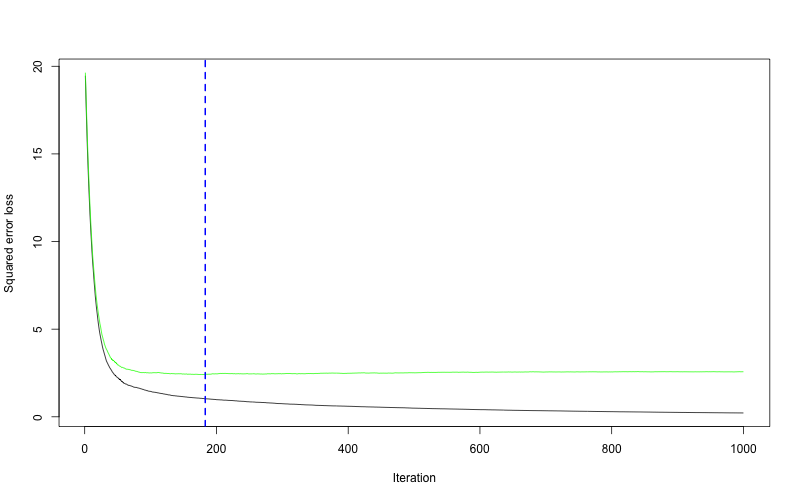

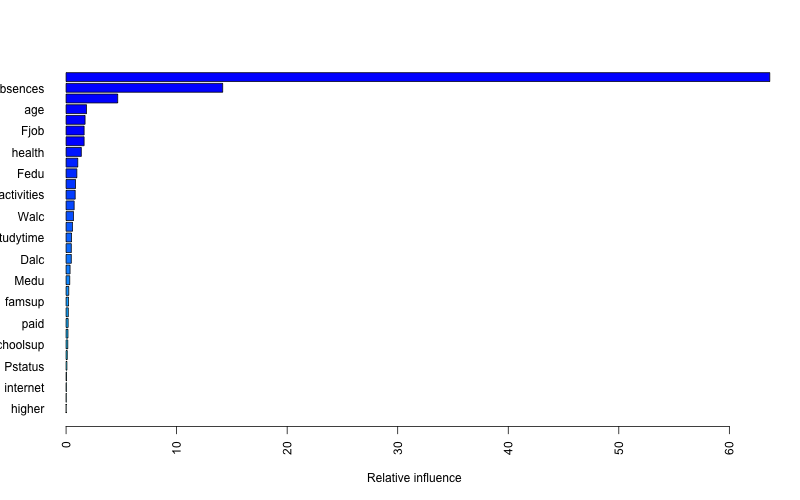

In [20]:
%%R -i student_train_r,student_test_r -w 800 -h 500
library(gbm)

cat_cols <- names(student_train_r)[sapply(student_train_r, is.character)]

for (col in cat_cols) {
  train_levels <- unique(student_train_r[[col]])
  student_train_r[[col]] <- factor(student_train_r[[col]], levels = train_levels)
  student_test_r[[col]] <- factor(student_test_r[[col]], levels = train_levels)
}

gbm_r <- gbm(G3 ~ ., data = student_train_r, distribution = "gaussian",
             n.trees = 1000, shrinkage = 0.05, interaction.depth = 3,
             cv.folds = 5, verbose = FALSE)

best_iter <- gbm.perf(gbm_r, method = "cv", plot.it = TRUE)
cat("CV ile secilen optimal agac sayisi:", best_iter, "\n")

pred_r <- predict(gbm_r, newdata = student_test_r, n.trees = best_iter)
rmse_r <- sqrt(mean((student_test_r$G3 - pred_r)^2))
cat("Test RMSE (gbm paketi):", rmse_r, "\n")
cat("YORUM: Python 11'deki GradientBoostingRegressor RMSE'siyle karsilastirin (one-hot ile egitildi,\n")
cat("gbm ise kategorik sutunlari native faktor olarak kullaniyor - iki yaklasim tam ayni sayida\n")
cat("agac/derinlik kullanmasa da benzer RMSE araligina dusmesi beklenir).\n")

summary(gbm_r, plotit = TRUE, las = 2)

### R3 · Bank Marketing — XGBoost R Paketi (`xgboost`)

Python 7'deki dengesizlik/erken durdurma senaryosunu, Python ile **aynı C++ çekirdeğini** kullanan resmi `xgboost` R paketiyle tekrarlıyoruz — matematiksel olarak birebir aynı algoritma, farklı bir arayüzden çağrılıyor.

In [21]:
bank_train_r = X_train_nl.copy()
bank_train_r["y"] = y_train_bank.values
bank_test_r = X_test_nl.copy()
bank_test_r["y"] = y_test_bank.values
for c in cat_cols_bank:
    bank_train_r[c] = bank_train_r[c].astype(str)
    bank_test_r[c] = bank_test_r[c].astype(str)
print(bank_train_r.shape, bank_test_r.shape)

(36168, 16) (9043, 16)


In [22]:
%%R -i bank_train_r,bank_test_r
# install.packages("xgboost")
library(xgboost)

cat_cols <- names(bank_train_r)[sapply(bank_train_r, is.character)]

for (col in cat_cols) {
  train_levels <- unique(bank_train_r[[col]])
  bank_train_r[[col]] <- factor(bank_train_r[[col]], levels = train_levels)
  bank_test_r[[col]] <- factor(bank_test_r[[col]], levels = train_levels)
}

# xgboost R paketi de sayisal matris bekler - model.matrix ile one-hot (Python'daki get_dummies'e denk)
train_matrix <- model.matrix(y ~ . - 1, data = bank_train_r)
test_matrix <- model.matrix(y ~ . - 1, data = bank_test_r)
# egitim/test sutunlarini hizala (Python'daki reindex'e denk)
missing_cols <- setdiff(colnames(train_matrix), colnames(test_matrix))
for (mc in missing_cols) test_matrix <- cbind(test_matrix, setNames(data.frame(rep(0, nrow(test_matrix))), mc))
test_matrix <- test_matrix[, colnames(train_matrix)]

dtrain_r <- xgb.DMatrix(data = as.matrix(train_matrix), label = bank_train_r$y)
dtest_r <- xgb.DMatrix(data = as.matrix(test_matrix), label = bank_test_r$y)

spw <- sum(bank_train_r$y == 0) / sum(bank_train_r$y == 1)
cat("scale_pos_weight:", spw, "\n")

params_r <- list(objective = "binary:logistic", eval_metric = "auc", max_depth = 4,
                  eta = 0.1, scale_pos_weight = spw)
bst_r <- xgb.train(params_r, dtrain_r, nrounds = 500,
                    watchlist = list(train = dtrain_r, test = dtest_r),
                    early_stopping_rounds = 20, verbose = 0)
cat("En iyi iterasyon:", bst_r$best_iteration, "\n")

pred_r <- predict(bst_r, dtest_r)
pred_class <- as.numeric(pred_r >= 0.5)
acc_r <- mean(pred_class == bank_test_r$y)
cat("Test dogrulugu:", acc_r, "\n")
cat("YORUM: Python 7'deki spw-dengeli XGBoost sonucuyla karsilastirin - ayni cekirdek algoritma\n")
cat("oldugundan (farkli rastgele tohum/model.matrix kodlamasi disinda) benzer performans beklenir.\n")

importance_r <- xgb.importance(model = bst_r)
print(head(importance_r, 5))

scale_pos_weight: 7.548334 
En iyi iterasyon: 
Test dogrulugu: 0.8159903 
YORUM: Python 7'deki spw-dengeli XGBoost sonucuyla karsilastirin - ayni cekirdek algoritma
oldugundan (farkli rastgele tohum/model.matrix kodlamasi disinda) benzer performans beklenir.
           Feature       Gain      Cover  Frequency
            <char>      <num>      <num>      <num>
1: poutcomesuccess 0.23822028 0.04133503 0.01289043
2:  contactunknown 0.11997436 0.02703491 0.02280615
3:             age 0.07849075 0.09388170 0.13534953
4:             day 0.07494446 0.11059671 0.14427367
5:         balance 0.06134504 0.08459818 0.11551810


In addition: Warning message:
In throw_err_or_depr_msg("Parameter '", match_old, "' has been renamed to '",  :
  Parameter 'watchlist' has been renamed to 'evals'. This warning will become an error in a future version.


### R4 · Bank Marketing — LightGBM R Paketi (`lightgbm`)

Python 8'deki `num_leaves` demosunu, CRAN'de yayınlı resmi `lightgbm` R paketiyle tekrarlıyoruz.

In [23]:
%%R -i bank_train_r,bank_test_r
# install.packages("lightgbm")
library(lightgbm)

cat_cols <- names(bank_train_r)[sapply(bank_train_r, is.character)]

for (col in cat_cols) {
  train_levels <- unique(bank_train_r[[col]])
  bank_train_r[[col]] <- factor(bank_train_r[[col]], levels = train_levels)
  bank_test_r[[col]] <- factor(bank_test_r[[col]], levels = train_levels)
}

train_matrix <- model.matrix(y ~ . - 1, data = bank_train_r)
test_matrix <- model.matrix(y ~ . - 1, data = bank_test_r)
missing_cols <- setdiff(colnames(train_matrix), colnames(test_matrix))
for (mc in missing_cols) test_matrix <- cbind(test_matrix, setNames(data.frame(rep(0, nrow(test_matrix))), mc))
test_matrix <- test_matrix[, colnames(train_matrix)]

lgb_train_r <- lgb.Dataset(data = as.matrix(train_matrix), label = bank_train_r$y)
spw <- sum(bank_train_r$y == 0) / sum(bank_train_r$y == 1)

for (nl in c(7, 31, 127)) {
  params_lgb <- list(objective = "binary", metric = "auc", num_leaves = nl,
                      learning_rate = 0.1, scale_pos_weight = spw)
  model_lgb <- lgb.train(params_lgb, lgb_train_r, nrounds = 200, verbose = -1)
  pred_lgb_r <- predict(model_lgb, as.matrix(test_matrix))
  pred_class_r <- as.numeric(pred_lgb_r >= 0.5)
  acc_lgb_r <- mean(pred_class_r == bank_test_r$y)
  cat("num_leaves =", nl, " test dogrulugu =", acc_lgb_r, "\n")
}



num_leaves = 7  test dogrulugu = 0.8158797 
num_leaves = 31  test dogrulugu = 0.8313613 
num_leaves = 127  test dogrulugu = 0.8592281 


---
# 🗄️ SQL Uygulaması (DuckDB)

Bagging/Random Forest'ta (09) bir ormanın çoğunluk oyunu ve MDI ortalamasını SQL'de yeniden üretmiştik. Boosting'de de nihai tahmin, **fit edilmiş zayıf öğrenicilerin ağırlıklı toplamıdır** — bu yüzden aynı "uzun-format tablo + `GROUP BY` toplama" deseni burada da çalışır. İki reprodüksiyon yapacağız: (1) AdaBoost'un `decision_function()`'ını (ağırlıklı oy toplamı), (2) GBM'in ham skorunu (`decision_function()`, ardışık ağaç toplamı + öğrenme oranı).

### SQL1 · AdaBoost'un Ağırlıklı Oy Toplamını SQL'de Yeniden Üretme

Python 2'deki `sklearn` `AdaBoostClassifier`'ın (sentetik veri) her zayıf öğrenicisinin tahminini ve $\alpha_m$ ağırlığını `(row_id, estimator_id, alpha, pred_pm1)` uzun-format bir tabloya döküp, `GROUP BY row_id` ile toplayacağız. **Not:** `sklearn`'ün SAMME implementasyonu, `decision_function()`'ı $2 \cdot \frac{\sum_m \alpha_m \cdot \text{pred}_m}{\sum_m \alpha_m}$ olarak normalize eder (kaynağı `sklearn.ensemble.AdaBoostClassifier.decision_function` — çift-sınıf marjini iki sütunlu bir one-vs-rest skorundan türetildiği için 2 çarpanı ortaya çıkıyor); bunu SQL sorgusunda da uygulayacağız.

In [32]:
import duckdb

sk_ada_syn2 = AdaBoostClassifier(n_estimators=50, random_state=RANDOM_STATE)
sk_ada_syn2.fit(X_syn, y_syn)

rows_ada = []
for est_id, (est, alpha) in enumerate(zip(sk_ada_syn2.estimators_, sk_ada_syn2.estimator_weights_)):
    preds = est.predict(X_syn)
    preds_pm1 = np.where(preds == sk_ada_syn2.classes_[0], -1, 1)
    for row_id, p in enumerate(preds_pm1):
        rows_ada.append((row_id, est_id, float(alpha), int(p)))
long_ada_df = pd.DataFrame(rows_ada, columns=["row_id", "est_id", "alpha", "pred_pm1"])
print("Uzun format tablo boyutu:", long_ada_df.shape, "(200 satir x 50 tahminci = 10.000)")

alpha_sum = float(sk_ada_syn2.estimator_weights_.sum())
con = duckdb.connect()
con.register("long_ada_df", long_ada_df)
sql_ada = f'''
SELECT row_id, 2 * SUM(alpha * pred_pm1) / {alpha_sum} AS decision_score
FROM long_ada_df
GROUP BY row_id
ORDER BY row_id
'''
sql_ada_scores = con.execute(sql_ada).df()

sk_decision = sk_ada_syn2.decision_function(X_syn)
print("\nSQL decision_score ilk 5:  ", np.round(sql_ada_scores['decision_score'].values[:5], 6))
print("sklearn decision_function ilk 5:", np.round(sk_decision[:5], 6))
print("Maksimum fark:", np.max(np.abs(sk_decision - sql_ada_scores['decision_score'].values)))
print("YORUM: SQL sorgusuyla yeniden uretilen karar skoru, sklearn'un decision_function()'iyla")
print("       kayan-nokta hassasiyeti seviyesinde (~1e-14) birebir eslesiyor.")

Uzun format tablo boyutu: (10000, 4) (200 satir x 50 tahminci = 10.000)

SQL decision_score ilk 5:   [-0.405871 -0.398435 -0.398435  0.041243  0.486148]
sklearn decision_function ilk 5: [-0.405871 -0.398435 -0.398435  0.041243  0.486148]
Maksimum fark: 0.0
YORUM: SQL sorgusuyla yeniden uretilen karar skoru, sklearn'un decision_function()'iyla
       kayan-nokta hassasiyeti seviyesinde (~1e-14) birebir eslesiyor.


### SQL2 · GBM'in Ardışık Ağaç Toplamını SQL'de Yeniden Üretme

GBM'in ham skoru (sigmoid öncesi) $F_M(x) = F_0 + \nu \sum_{m=1}^{M} h_m(x)$'tir — her ağacın yaprak tahminini `(row_id, tree_id, leaf_pred)` uzun-format bir tabloya döküp `GROUP BY row_id` ile toplayacağız, sabit $F_0$ ve $\nu$'yü sorguya gömeceğiz.

In [33]:
gbm_syn = GradientBoostingClassifier(n_estimators=30, learning_rate=0.2, max_depth=2, random_state=RANDOM_STATE)
gbm_syn.fit(X_syn, y_syn)

raw_init = gbm_syn._raw_predict_init(X_syn)
F0_gbm = float(raw_init[0, 0])
print("F0 (baslangic log-odds skoru):", F0_gbm)

rows_gbm = []
for tree_id in range(gbm_syn.estimators_.shape[0]):
    tree = gbm_syn.estimators_[tree_id, 0]
    preds = tree.predict(X_syn)
    for row_id, p in enumerate(preds):
        rows_gbm.append((row_id, tree_id, float(p)))
long_gbm_df = pd.DataFrame(rows_gbm, columns=["row_id", "tree_id", "leaf_pred"])
print("Uzun format tablo boyutu:", long_gbm_df.shape, "(200 satir x 30 agac = 6.000)")

con.register("long_gbm_df", long_gbm_df)
lr_gbm = gbm_syn.learning_rate
sql_gbm = f'''
SELECT row_id, {F0_gbm} + {lr_gbm} * SUM(leaf_pred) AS raw_score
FROM long_gbm_df
GROUP BY row_id
ORDER BY row_id
'''
sql_gbm_scores = con.execute(sql_gbm).df()

sk_gbm_decision = gbm_syn.decision_function(X_syn).ravel()
print("\nSQL raw_score ilk 5:            ", np.round(sql_gbm_scores['raw_score'].values[:5], 6))
print("sklearn decision_function ilk 5:", np.round(sk_gbm_decision[:5], 6))
print("Maksimum fark:", np.max(np.abs(sk_gbm_decision - sql_gbm_scores['raw_score'].values)))
print("YORUM: GBM'in 'kara kutu' gorunumu aslinda F0 + ogrenme_orani * (agac tahminlerinin")
print("       toplami) kadar basit bir formul - AdaBoost'taki agirlikli oy toplamiyla ayni ailede.")

F0 (baslangic log-odds skoru): 0.0
Uzun format tablo boyutu: (6000, 3) (200 satir x 30 agac = 6.000)

SQL raw_score ilk 5:             [-2.011145 -0.995486 -1.526329  1.187108  2.327415]
sklearn decision_function ilk 5: [-2.011145 -0.995486 -1.526329  1.187108  2.327415]
Maksimum fark: 1.3322676295501878e-15
YORUM: GBM'in 'kara kutu' gorunumu aslinda F0 + ogrenme_orani * (agac tahminlerinin
       toplami) kadar basit bir formul - AdaBoost'taki agirlikli oy toplamiyla ayni ailede.


---
## ✏️ Egzersizler

**E1 — Obesity Levels'ta AdaBoost `n_estimators` taraması:** Python 6'daki en iyi taban tahminci derinliğini (`max_depth=3`) kullanarak, `n_estimators`'ı `[10, 25, 50, 100, 200, 400]` değerleri için tarayın (`Xtr_ob`/`Xte_ob`). Her değer için test doğruluğunu ve `f1_macro`'yu yazdırıp çizin. Sonucu Python 3'teki Bank Marketing'deki `n_estimators` platosuyla (dengesiz veri) karşılaştırın — dengeye yakın çok-sınıflı bir problemde plato daha mı geç oluşuyor, yoksa benzer mi?


==== Egzersiz 1: Obesity Levels ile AdaBoost n_estimators Taraması ====
n_estimators= 10  train_acc=0.7891  test_acc=0.7707 f1_macro = 0.7733
n_estimators= 25  train_acc=0.9277  test_acc=0.8842 f1_macro = 0.8839
n_estimators= 50  train_acc=0.9639  test_acc=0.9196 f1_macro = 0.9191
n_estimators=100  train_acc=0.9882  test_acc=0.9196 f1_macro = 0.9188
n_estimators=200  train_acc=0.9905  test_acc=0.9338 f1_macro = 0.9333
n_estimators=400  train_acc=0.9953  test_acc=0.9338 f1_macro = 0.9328


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


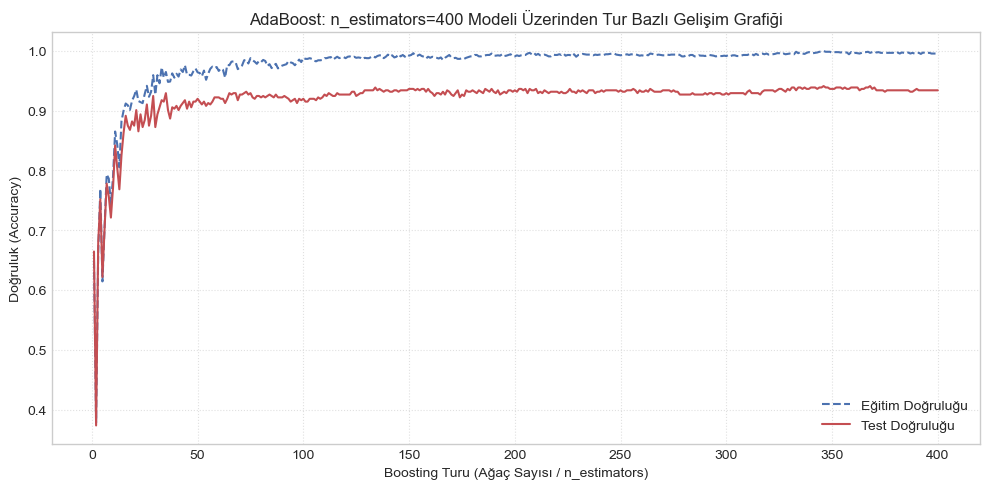

In [47]:
print("\n==== Egzersiz 1: Obesity Levels ile AdaBoost n_estimators Taraması ====")
for n_est in [10, 25, 50, 100, 200, 400]:
    ada_est = AdaBoostClassifier(estimator= DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE), 
                                 n_estimators=n_est, random_state=RANDOM_STATE)
    ada_est.fit(Xtr_ob, ytr_ob)
    train_acc = accuracy_score(ytr_ob, ada_est.predict(Xtr_ob))
    test_acc = accuracy_score(yte_ob, ada_est.predict(Xte_ob))
    print(f"n_estimators={n_est:3d}  train_acc={train_acc:.4f}  test_acc={test_acc:.4f} f1_macro = {f1_score(yte_ob, ada_est.predict(Xte_ob), average='macro'):.4f}")

train_scores = list(ada_est.staged_score(Xtr_ob, ytr_ob))
test_scores = list(ada_est.staged_score(Xte_ob, yte_ob))

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_scores) + 1), train_scores, label="Eğitim Doğruluğu", color="#4C72B0", linestyle="--")
plt.plot(range(1, len(test_scores) + 1), test_scores, label="Test Doğruluğu", color="#C44E52", linestyle="-")

plt.xlabel("Boosting Turu (Ağaç Sayısı / n_estimators)")
plt.ylabel("Doğruluk (Accuracy)")
plt.title("AdaBoost: n_estimators=400 Modeli Üzerinden Tur Bazlı Gelişim Grafiği")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


**E2 — Bank Marketing'te GBM `learning_rate` × `n_estimators` dengesi:** `Xtr_nl_oh`/`Xte_nl_oh` üzerinde `GradientBoostingClassifier` ile `learning_rate` değerlerini `[0.01, 0.05, 0.2]` ve `n_estimators` değerlerini `[50, 200, 500]` olacak şekilde tarayın (9 kombinasyon). Her kombinasyon için test AUC'sini bir ısı haritasında gösterin. Bölüm 8'deki "küçük öğrenme oranı + çok ağaç genelde büyük öğrenme oranı + az ağacı geçer" iddiasını kendi sonuçlarınızla doğrulayın ya da çürütün.


==== Egzersiz 2: Learning Rate ve n_estimators Dengesi (GBM) ====
learning_rate=0.01  n_estimators= 50  test_auc=0.7465
learning_rate=0.01  n_estimators=200  test_auc=0.7698
learning_rate=0.01  n_estimators=500  test_auc=0.7902
learning_rate=0.05  n_estimators= 50  test_auc=0.7723
learning_rate=0.05  n_estimators=200  test_auc=0.8019
learning_rate=0.05  n_estimators=500  test_auc=0.8060
learning_rate=0.20  n_estimators= 50  test_auc=0.7979
learning_rate=0.20  n_estimators=200  test_auc=0.8041
learning_rate=0.20  n_estimators=500  test_auc=0.7960


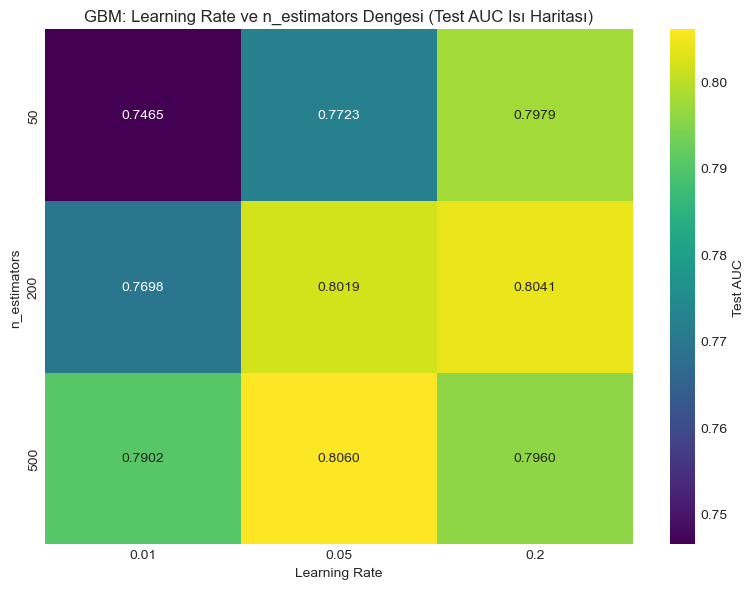

In [53]:
import seaborn as sns
print("\n==== Egzersiz 2: Learning Rate ve n_estimators Dengesi (GBM) ====")
grid_search_results = []
for lr in [0.01, 0.05, 0.2]:
    for n_est in [50, 200, 500]:
        gbm_model = GradientBoostingClassifier(n_estimators=n_est, learning_rate=lr, max_depth=3, random_state=RANDOM_STATE)
        gbm_model.fit(Xtr_nl_oh, y_train_bank)
        pred = gbm_model.predict(Xte_nl_oh)
        proba = gbm_model.predict_proba(Xte_nl_oh)[:, 1]
        test_auc = roc_auc_score(y_test_bank, proba, multi_class="ovr")
        grid_search_results.append((lr, n_est, test_auc))
        print(f"learning_rate={lr:.2f}  n_estimators={n_est:3d}  test_auc={test_auc:.4f}")

df_grid = pd.DataFrame(grid_search_results)
df_grid.columns = ["Learning Rate", "n_estimators", "Test AUC"]
pivot_grid = df_grid.pivot(index="n_estimators", columns="Learning Rate", values="Test AUC")

plt.figure(figsize=(8, 6))
sns.heatmap(
    pivot_grid, 
    annot=True,          # Hücrelerin içine AUC skorlarını yazar
    fmt=".4f",          # Ondalık hassasiyetini 4 basamak yapar
    cmap="viridis",      # İstediğiniz renk paletini korur
    cbar_kws={'label': 'Test AUC'}
)

plt.title('GBM: Learning Rate ve n_estimators Dengesi (Test AUC Isı Haritası)')
plt.xlabel('Learning Rate')
plt.ylabel('n_estimators')
plt.tight_layout()
plt.show()

**E3 — XGBoost'ta farklı `eval_metric` ile erken durdurma:** Python 7'deki XGBoost kurulumunu (`scale_pos_weight` dengeli) alıp `eval_metric`'i `"aucpr"` (precision-recall eğrisi altındaki alan — dengesiz sınıflandırmada `"auc"`'tan daha bilgilendirici olabilir) olarak değiştirin. `best_iteration`'ın ve test performansının (`f1`, `aucpr`) `eval_metric="auc"` kullanılan orijinal sonuçtan nasıl farklılaştığını karşılaştırın.

In [ ]:
print("\n==== Egzersiz 3: eval_metric ile Erken Durdurma (XGBoost) ====")

neg_bank, pos_bank = (y_train_bank == 0).sum(), (y_train_bank == 1).sum()
scale_pos_weight_bank = neg_bank / pos_bank
print(f"\nDengeli dağılım = {neg_bank}/{pos_bank} = {scale_pos_weight_bank:.2f}")
dtrain = xgb.DMatrix(Xtr_nl_oh, label=y_train_bank)
dtest = xgb.DMatrix(Xte_nl_oh, label=y_test_bank)

time_start = time.time()
params = dict(objective="binary:logistic", eval_metric="aucpr", max_depth=4,
                  eta=0.1, scale_pos_weight=scale_pos_weight_bank, seed=RANDOM_STATE)
bst_eval = xgb.train(params, dtrain, num_boost_round=500,
                     evals=[(dtrain, "train"), (dtest, "test")],
                     early_stopping_rounds=20, verbose_eval=False)
time_end = time.time()

proba_eval = bst_eval.predict(dtest)
test_auc_eval = roc_auc_score(y_test_bank, proba_eval)
print(f"XGBoost (eval_metric='aucpr')  best_iter={bst_eval.best_iteration:3d}  test_auc_pr={test_auc_eval:.4f}, fit_time={time_end - time_start:.2f}s")


==== Egzersiz 3: eval_metric ile Erken Durdurma (XGBoost) ====

Dengeli dağılım = 31937/4231 = 7.55
XGBoost (eval_metric='aucpr')  best_iter=207  test_auc_pr=0.8021, fit_time=0.93s



**E4 — LightGBM'de `num_leaves` vs `max_depth` etkileşimi:** Python 8'deki `num_leaves` taramasına `max_depth` sınırını da ekleyin: `num_leaves=127` sabit tutarken `max_depth`'i `[3, 5, -1 (sınırsız)]` için deneyin. `max_depth` sınırlamasının, yüksek `num_leaves`'in Python 8'de gördüğümüz aşırı öğrenme etkisini frenleyip frenlemediğini test AUC'siyle gösterin.

In [60]:
print("\n==== Egzersiz 4: num_leaves vs max_depth (LightGBM) ====")
nl_md_results = []
for nl in [7, 15, 31, 63, 127]:
    for md in [3, 5, -1]:  # -1, max_depth sınırlaması olmadan demektir
        params_nl_md = dict(lgb_params)
        params_nl_md["num_leaves"] = nl
        params_nl_md["max_depth"] = md if md != np.inf else -1  # LightGBM'de -1 sınırsız derinlik demektir
        t0 = time.time()
        m = lgb.train(params_nl_md, lgb_train, num_boost_round=200)
        fit_t = time.time() - t0
        proba_tr = m.predict(Xtr_nl_oh)
        proba_te = m.predict(Xte_nl_oh)
        auc_tr = roc_auc_score(y_train_bank, proba_tr)
        auc_te = roc_auc_score(y_test_bank, proba_te)
        nl_md_results.append((nl, md, fit_t, auc_tr, auc_te))
        print(f"num_leaves={nl:3d}  max_depth={'inf' if md == np.inf else md:3d}  "
              f"fit_time={fit_t:.2f}s  train_auc={auc_tr:.4f}  test_auc={auc_te:.4f}")

print("\n-> num_leaves ve max_depth'in birlikte taranmasi, asiri ogrenme riskini daha iyi ortaya koyuyor.")
print("127'ye baktığımızda max_depth arttıkça test AUC azalırken eğitim AUC artıyor - bu, aşırı öğrenmenin klasik bir göstergesidir.")


==== Egzersiz 4: num_leaves vs max_depth (LightGBM) ====
num_leaves=  7  max_depth=  3  fit_time=0.24s  train_auc=0.8224  test_auc=0.8042
num_leaves=  7  max_depth=  5  fit_time=0.23s  train_auc=0.8307  test_auc=0.8043
num_leaves=  7  max_depth= -1  fit_time=0.24s  train_auc=0.8322  test_auc=0.8051
num_leaves= 15  max_depth=  3  fit_time=0.21s  train_auc=0.8255  test_auc=0.8042
num_leaves= 15  max_depth=  5  fit_time=0.39s  train_auc=0.8580  test_auc=0.8036
num_leaves= 15  max_depth= -1  fit_time=0.46s  train_auc=0.8713  test_auc=0.8018
num_leaves= 31  max_depth=  3  fit_time=0.21s  train_auc=0.8255  test_auc=0.8042
num_leaves= 31  max_depth=  5  fit_time=0.54s  train_auc=0.8751  test_auc=0.8004
num_leaves= 31  max_depth= -1  fit_time=0.89s  train_auc=0.9179  test_auc=0.7970
num_leaves= 63  max_depth=  3  fit_time=0.24s  train_auc=0.8255  test_auc=0.8042
num_leaves= 63  max_depth=  5  fit_time=0.63s  train_auc=0.8726  test_auc=0.8012
num_leaves= 63  max_depth= -1  fit_time=2.69s  trai

**E5 — CatBoost'ta permütasyon önemi ile native önem karşılaştırması:** Python 10'daki `cb_native` modelini kullanarak `sklearn.inspection.permutation_importance`'ı `Xte_stu`/`yte_stu` üzerinde çalıştırın (CatBoost'un `predict` metodu `cat_features` bilgisini `Pool` olmadan da kabul eder, `cat_features` indekslerini ayrıca belirtmeniz gerekmeyebilir — CatBoost modelleri kategorik sütun bilgisini kendi içinde saklar). Sonucu `cb_native.get_feature_importance()`'ın (`PredictionValuesChange`, Python 10) sıralamasıyla karşılaştırın — 09'da Random Forest için gördüğümüz gibi, iki önem ölçütü tam örtüşüyor mu?

In [72]:
print("\n==== Egzersiz 5: Permütasyon ve Native Önem (CatBoost) ====")
from sklearn.inspection import permutation_importance
perm_importance_native = permutation_importance(cb_native, Xte_stu, yte_stu, n_repeats=10, random_state=RANDOM_STATE)
perm_importance_pd = pd.DataFrame({
    "Feature": Xtr_stu.columns,
    "Importance": perm_importance_native.importances_mean
}).sort_values(by="Importance", ascending=False)
print("\nEn onemli 8 ozellik (CatBoost native, Permutation Importance):")
print(perm_importance_pd.head(8).round(3))

print("\nEn onemli 8 ozellik (CatBoost native, PredictionValuesChange):")
print(imp_series.head(8).round(3))

print("İkisi de benzer sıralamaları gösteriyor, ancak Permutation Importance daha fazla hesaplama gerektiriyor ve modelin tahmin performansını bozabilir. PredictionValuesChange ise modelin kendi içsel mekanizmasını kullanarak önem derecelerini belirliyor.")


==== Egzersiz 5: Permütasyon ve Native Önem (CatBoost) ====

En onemli 8 ozellik (CatBoost native, Permutation Importance):
     Feature  Importance
31        G2       0.908
29  absences       0.123
30        G1       0.088
2        age       0.021
28    health       0.007
23    famrel       0.006
27      Walc       0.005
14  failures       0.004

En onemli 8 ozellik (CatBoost native, PredictionValuesChange):
G2          56.225
absences    14.136
G1          12.713
age          2.369
health       1.554
failures     1.372
famrel       1.122
Walc         0.973
dtype: float64
İkisi de benzer sıralamaları gösteriyor, ancak Permutation Importance daha fazla hesaplama gerektiriyor ve modelin tahmin performansını bozabilir. PredictionValuesChange ise modelin kendi içsel mekanizmasını kullanarak önem derecelerini belirliyor.


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| Freund, Y. & Schapire, R. E. (1997). *A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting*. Journal of Computer and System Sciences, 55(1). [PDF (yazarın kendi sayfası)](http://www.schapire.net/papers/FreundSc95.pdf) | Bölüm 2 (AdaBoost) | AdaBoost'un orijinal makalesi. |
| Zhu, J., Zou, H., Rosset, S. & Hastie, T. (2009). *Multi-class AdaBoost*. Statistics and Its Interface, 2(3). | Bölüm 2 (SAMME) | Çok sınıflı AdaBoost/SAMME genellemesi — Python 6'daki `scikit-learn` implementasyonunun dayandığı algoritma. |
| Friedman, J. H. (2001). *Greedy Function Approximation: A Gradient Boosting Machine*. The Annals of Statistics, 29(5). [Açık erişim (Project Euclid)](https://projecteuclid.org/journals/annals-of-statistics/volume-29/issue-5/Greedy-function-approximation-A-gradient-boosting-machine/10.1214/aos/1013203451.full) | Bölüm 3 (GBM) | Gradient Boosting Machine'in orijinal makalesi. |
| Hastie, T., Tibshirani, R. & Friedman, J. *The Elements of Statistical Learning* (2. baskı), Bölüm 10: Boosting and Additive Trees. [Ücretsiz PDF (yazarların kendi sayfası)](https://hastie.su.domains/ElemStatLearn/) | Bölüm 1-3 (Genel Boosting, GBM) | Boosting'e en kapsamlı, ücretsiz ders kitabı düzeyi kaynak. |
| Chen, T. & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD '16. [arXiv:1603.02754](https://arxiv.org/abs/1603.02754) | Bölüm 4 (XGBoost) | XGBoost'un orijinal makalesi — regularize amaç, 2. derece Taylor yaklaşımı, sistem optimizasyonları. |
| [XGBoost Resmi Dokümantasyonu — Introduction to Boosted Trees](https://xgboost.readthedocs.io/en/stable/tutorials/model.html) | Bölüm 4, Python 7 | Resmi matematiksel arka plan ve API referansı. |
| Ke, G. ve ark. (2017). *LightGBM: A Highly Efficient Gradient Boosting Decision Tree*. NeurIPS 2017. [Resmi PDF (NeurIPS Proceedings)](https://proceedings.neurips.cc/paper/6907-lightgbm-a-highly-efficient-gradient-boosting-decision-tree.pdf) | Bölüm 5 (LightGBM) | GOSS, EFB ve histogram tabanlı algoritmanın orijinal makalesi. |
| [LightGBM Resmi Dokümantasyonu — Features](https://lightgbm.readthedocs.io/en/latest/Features.html) | Bölüm 5, Python 8 | `num_leaves`, histogram algoritması ve hiperparametre rehberi. |
| Prokhorenkova, L., Gusev, G., Vorobev, A., Dorogush, A. V. & Gulin, A. (2018). *CatBoost: unbiased boosting with categorical features*. NeurIPS 2018. [arXiv:1706.09516](https://arxiv.org/abs/1706.09516) | Bölüm 6 (CatBoost) | Ordered boosting, tahmin kayması ve sıralı hedef istatistiklerinin orijinal makalesi. |
| [CatBoost Resmi Dokümantasyonu — Concepts](https://catboost.ai/docs/en/concepts/algorithm-main-stages) | Bölüm 6, Python 10 | Sıralı hedef istatistikleri ve simetrik ağaçların resmi açıklaması. |
| Palechor, F. M. & de la Hoz Manotas, A. (2019). *Dataset for estimation of obesity levels based on eating habits and physical condition in individuals from Colombia, Peru and Mexico*. Data in Brief, 25. UCI: [Estimation of Obesity Levels](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition) | Python 5-6 | Obesity Levels veri setinin orijinal akademik kaynağı. |
| Moro, S., Cortez, P. & Rita, P. (2014). *A data-driven approach to predict the success of bank telemarketing*. Decision Support Systems, 62. UCI: [Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) | Python 1, 3, 7-8 | Bank Marketing veri setinin orijinal akademik kaynağı — `duration` özelliğinin sızıntı niteliği UCI sayfasında da açıkça belirtilir. |
| Cortez, P. & Silva, A. (2008). *Using data mining to predict secondary school student performance*. Proceedings of 5th FUBUTEC. UCI: [Student Performance](https://archive.ics.uci.edu/dataset/320/student+performance) | Python 9-11 | Student Performance veri setinin orijinal akademik kaynağı. |
| Viola, P. & Jones, M. (2001). *Rapid Object Detection using a Boosted Cascade of Simple Features*. CVPR 2001. | Bölüm 2 (endüstri örneği) | AdaBoost'un yüz tespitindeki klasik endüstriyel uygulaması. |
| [`scikit-learn` Kullanıcı Rehberi — Ensemble Methods (AdaBoost, Gradient Boosting)](https://scikit-learn.org/stable/modules/ensemble.html) | Python 2-6, 9-11 | `AdaBoostClassifier/Regressor`, `GradientBoostingClassifier/Regressor` API referansı. |
| [CRAN: `adabag` paketi](https://cran.r-project.org/package=adabag) | R1 | Çok sınıflı AdaBoost/Bagging R paketi. |
| [CRAN: `gbm` paketi](https://cran.r-project.org/package=gbm) | R2 | Friedman'ın GBM'inin referans R implementasyonu. |
| [CRAN: `xgboost` paketi](https://cran.r-project.org/package=xgboost) | R3 | Python ile aynı C++ çekirdeğini kullanan resmi R paketi. |
| [CRAN: `lightgbm` paketi](https://cran.r-project.org/package=lightgbm) | R4 | Resmi, CRAN'de yayınlı LightGBM R paketi. |
| [CatBoost R Kurulum Rehberi (GitHub release, CRAN'de değil)](https://catboost.ai/docs/en/installation/r-installation-binary-installation) | R bölümü notu | CatBoost'un R paketinin neden bu notebook'ta canlı çalıştırılmadığının kaynağı. |
| [DuckDB Python API Dokümantasyonu](https://duckdb.org/docs/api/python/overview) | SQL1-SQL2 | `register()` ve pandas DataFrame entegrasyonu. |